In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.special import kv
import scipy as sp
from scipy.stats import binned_statistic, mode,linregress
import calendar
import matplotlib.lines as mlines
from scipy.stats import linregress
import os



In [2]:

plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "legend.frameon": False
})


Marechiara dataset

In [ ]:

file_path = r"LTER-MC_Phyto_1984-2015.xlsx" # dataset from the supplementary files

sheet_name = "Data"

df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

Read dates and groups: each row of the file corresponds to a species, each column to a data. The mean distance between 2 consecutive samples is, in average, 7 days. Species are seprated in 4 groups with labels "1" (Diatoms), "2" (Dinoflagellates), "3" (Coccolithophores), "4" (Other flagellates).

In [9]:
start_col = 3
date_row = 1
raw_dates = df_raw.iloc[date_row, start_col:]
dates = pd.to_datetime(raw_dates, dayfirst=True, errors="coerce")
valid_mask = ~dates.isna()      # to avoid problems with the date notation
dates = dates[valid_mask].reset_index(drop=True)
time_days = (dates - dates.min()).dt.days.to_numpy()
months = dates.dt.month.to_numpy()

We check the distribuion of time intervalls:

In [10]:
delta_t = (dates[1:].to_numpy() - dates[:-1].to_numpy()) \
            .astype('timedelta64[D]') \
            .astype(int)

print("Number of samples:", len(delta_t))
print("Min distance (in days):", delta_t.min())
print("Max distance (in days):", delta_t.max())
print("Mean:", delta_t.mean())
print("Median:", np.median(delta_t))

Number of samples: 1159
Min distance (in days): 3
Max distance (in days): 1302
Mean: 10.06039689387403
Median: 7.0


By eliminating a big gap of a couple of years, the median is 7 days:

Number of itnervall <=365 days: 1040
Number of samples: 1040
Min distance (in days): 3
Max distance (in days): 14
Mean: 7.775
Median: 7.0


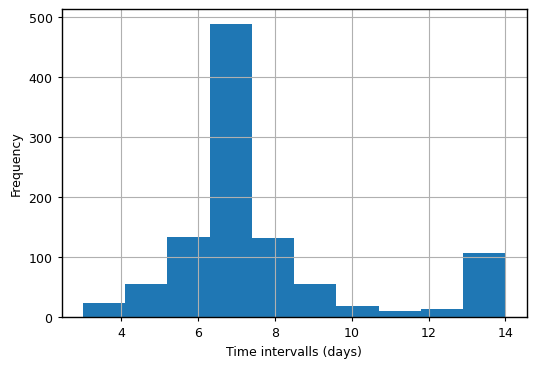

In [11]:
delta_t_filtered = delta_t[delta_t <= 14]

print("Number of itnervall <=365 days:", len(delta_t_filtered))
print("Number of samples:", len(delta_t_filtered))
print("Min distance (in days):", delta_t_filtered.min())
print("Max distance (in days):", delta_t_filtered.max())
print("Mean:", delta_t_filtered.mean())
print("Median:", np.median(delta_t_filtered))



plt.figure(figsize=(6,4))
plt.hist(delta_t_filtered, bins=10)
plt.xlabel("Time intervalls (days)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Here we eliminates the unclassified species

In [ ]:
rows = np.arange(7, 324) 

chars = df_raw.iloc[rows, 2].astype(str).str.lower().str.strip()
bad = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
valid = rows[~chars.isin(bad)]

original_groups = pd.to_numeric(df_raw.iloc[valid, 0], errors="coerce").to_numpy()
original_species_names = df_raw.iloc[valid, 1].astype(str).str.strip().to_numpy()

species_matrix_raw = df_raw.iloc[valid, 3:].apply(pd.to_numeric, errors="coerce")


# comparison with list of classified species
new_csv_path = r"species_filter.csv" #supplementary file
df_new_csv = pd.read_csv(new_csv_path)

species_to_keep = df_new_csv.iloc[:, 1].astype(str).str.strip().to_numpy()

# filter
keep_mask = np.isin(original_species_names, species_to_keep)
species_matrix = species_matrix_raw.loc[keep_mask].reset_index(drop=True)
groups_labels = original_groups[keep_mask]

unique_groups = np.array([1, 2, 3])
base_groups = [1, 2, 3]

group_names = ["Diatoms", "Dinoflagellates", "Coccolithophores"]


df_groups = pd.DataFrame(0.0, index=np.arange(4), columns=species_matrix.columns)

# total abundances
for i in range(3):
    group_label = i + 1
    mask_group = (groups_labels == group_label)
    df_groups.loc[i] = species_matrix.loc[mask_group].sum(axis=0)

df_groups.loc[3] = df_groups.loc[0] + df_groups.loc[1] + df_groups.loc[2]

Seasons

In [13]:
season_names = ["Winter", "Spring", "Summer", "Autumn"]
season_masks = [
    (months == 12) | (months <= 2),
    (months >= 3) & (months <= 5),
    (months >= 6) & (months <= 8),
    (months >= 9) & (months <= 11)
]

Here we define six functions: the first one generates the PDF on a log-log scale from a sample; the second one evaluates the Generalized Inverse Gaussian (GIG) distribution; the third one fits a sample with the GIG on a log-log scale. The last three do the same tasks but with a lognormal distribution.

In [14]:
# GIG fit

def logGIG(n,b,c,mu):
    n = np.maximum(n,1e-12) # to stabilize the function
    return sp.stats.geninvgauss.logpdf(n, 2.0*mu - 1.0, np.sqrt(4.0*b/c), scale=np.sqrt(b*c))

def loglik_GIG(params, vecN):
    b, c, mu = params
    return -np.sum(logGIG(vecN,b,c,mu))

def fit_GIG(vecN, p0=None):
    if p0 is None:
        p0 = [np.min(vecN), 2*np.var(vecN)*np.mean(vecN), 0.5]
    res = sp.optimize.minimize(loglik_GIG, p0, args=(vecN,),
                               bounds=[(1/10000, None),(1,None),(-3,4)],
                               method="Nelder-Mead",
                               options={'maxiter':35000})
    return (res.x, res.fun) if res.success else (None, None)

def fit_bessel(vecN, x_vals, y_vals):
    mask = (x_vals>0) & (y_vals>0) & np.isfinite(y_vals)
    x_fit, y_fit = x_vals[mask], y_vals[mask]
    vecN = vecN[vecN>0]
    if len(x_fit) < 3:
        return None, None, None
    p0 = [np.min(vecN), 2*np.var(vecN)*np.mean(vecN), 0.5]
    try:
        popt, nll = fit_GIG(vecN, p0)
        if popt is None:
            return None, None, None
        n_plot = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 200)
        pdf_plot = np.exp(logGIG(n_plot, popt[0], popt[1], popt[2]))
        
        if np.all(np.isfinite(pdf_plot)) == False:
            return None, None, None
        return popt, (n_plot, pdf_plot), nll
    except Exception:
        return None, None, None


def compute_pdf_log(values, n_bins=20):
    values = np.asarray(values)
    values = values[values>0]
    if len(values) < 5:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), n_bins)
    pdf_vals, edges = np.histogram(values, bins=bins, density=True)
    centers = np.sqrt(edges[:-1]*edges[1:])
    return centers, pdf_vals


# lognormal fit
def logLognorm(n, mu, sigma):
    n = np.maximum(n, 1e-12)
    return -np.log(n * sigma * np.sqrt(2 * np.pi)) - ((np.log(n) - mu)**2) / (2 * sigma**2)

def loglik_Lognorm(params, vecN):
    mu, sigma = params
    return -np.sum(logLognorm(vecN, mu, sigma))

def fit_Lognorm_pdf(vecN, p0=None):
    if p0 is None:
        log_vecN = np.log(vecN[vecN > 0])
        p0 = [np.mean(log_vecN), np.std(log_vecN) + 1e-3]
        
    res = sp.optimize.minimize(loglik_Lognorm, p0, args=(vecN,),
                               bounds=[(None, None), (1e-5, None)], 
                               method="Nelder-Mead",
                               options={'maxiter': 5000})
    return (res.x, res.fun) if res.success else (None, None)

def fit_distribution(vecN, x_vals, y_vals):
    mask = (x_vals > 0) & (y_vals > 0) & np.isfinite(y_vals)
    x_fit = x_vals[mask]
    vecN = vecN[vecN > 0]
    
    if len(x_fit) < 3:
        return None, None, None
        
    popt, nll = fit_Lognorm_pdf(vecN)
    if popt is None:
        return None, None, None
        
    n_plot = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 200)
    pdf_plot = np.exp(logLognorm(n_plot, popt[0], popt[1]))
    return popt, (n_plot, pdf_plot), nll


Function to evaluate mode and geometric mean values

In [15]:
# mode values estimation

def mode_per_x_full(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    unique_x = np.unique(x)
    x_modes = []
    y_modes = []
    for xi in unique_x:
        mask = x == xi
        if np.any(mask):
            m = mode(np.log10(y[mask]), keepdims=False).mode
            if np.isfinite(m):
                x_modes.append(xi)
                y_modes.append(10**m)
    return np.array(x_modes), np.array(y_modes)


# geometric mean
    
def dynamic_log_binning(x, y, n_bins):
    x, y = np.asarray(x), np.asarray(y)
    bins = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins + 1)
    
    x_centers, geom_means, y_low, y_high, std_logs = [], [], [], [], []
    
    for i in range(n_bins):
        mask = (x >= bins[i]) & (x <= bins[i+1]) if i == n_bins - 1 else (x >= bins[i]) & (x < bins[i+1])
        n_points = np.sum(mask)
        
        if n_points > 0:
            x_centers.append(np.exp(np.mean(np.log(x[mask]))))
            vals = np.log10(y[mask])
            mean_log = np.mean(vals)
            
            std_log = np.std(vals, ddof=1) if n_points > 1 else np.nan
            geom_means.append(10**mean_log)
            
            if not np.isnan(std_log):
                y_low.append(10**(mean_log - std_log))
                y_high.append(10**(mean_log + std_log))
            else:
                y_low.append(10**mean_log)
                y_high.append(10**mean_log)
                
            std_logs.append(std_log)
            
    return np.array(x_centers), np.array(geom_means), np.array(y_low), np.array(y_high), np.array(std_logs)


def linear_model(x, b, a):
    return b * x + a


Per each month, we analyze:
* TAD , distribution of total abundances (per each group)
* SAD , frequency of the sum of abundances over one months. The distributions is evalued over the species of each group.
* Sigma scaling for total abundances, the square of the noise term as a function of total abundances. For each bin within the TAD, N, we find all the couples N(t+7 days)-N(t) imposing N(t)=N, then we take the mean of the squares and fit them with a line A + B N in the log log space. Since sampling times are not regular, we don't include consecutive values with time intervall larger than 9 days and shorter than 5. 
* Sigma scaling for species. As above, for each bin within the SAD, n, we find all the couples n(t+7 days)-n(t) imposing n(t)=n.

In [16]:
n_bins = 15     # for both SAD and TAD
tau = 7     # main time intervall (days)
n_months = 12
month_names = [calendar.month_name[i] for i in range(1,13)]

First check:

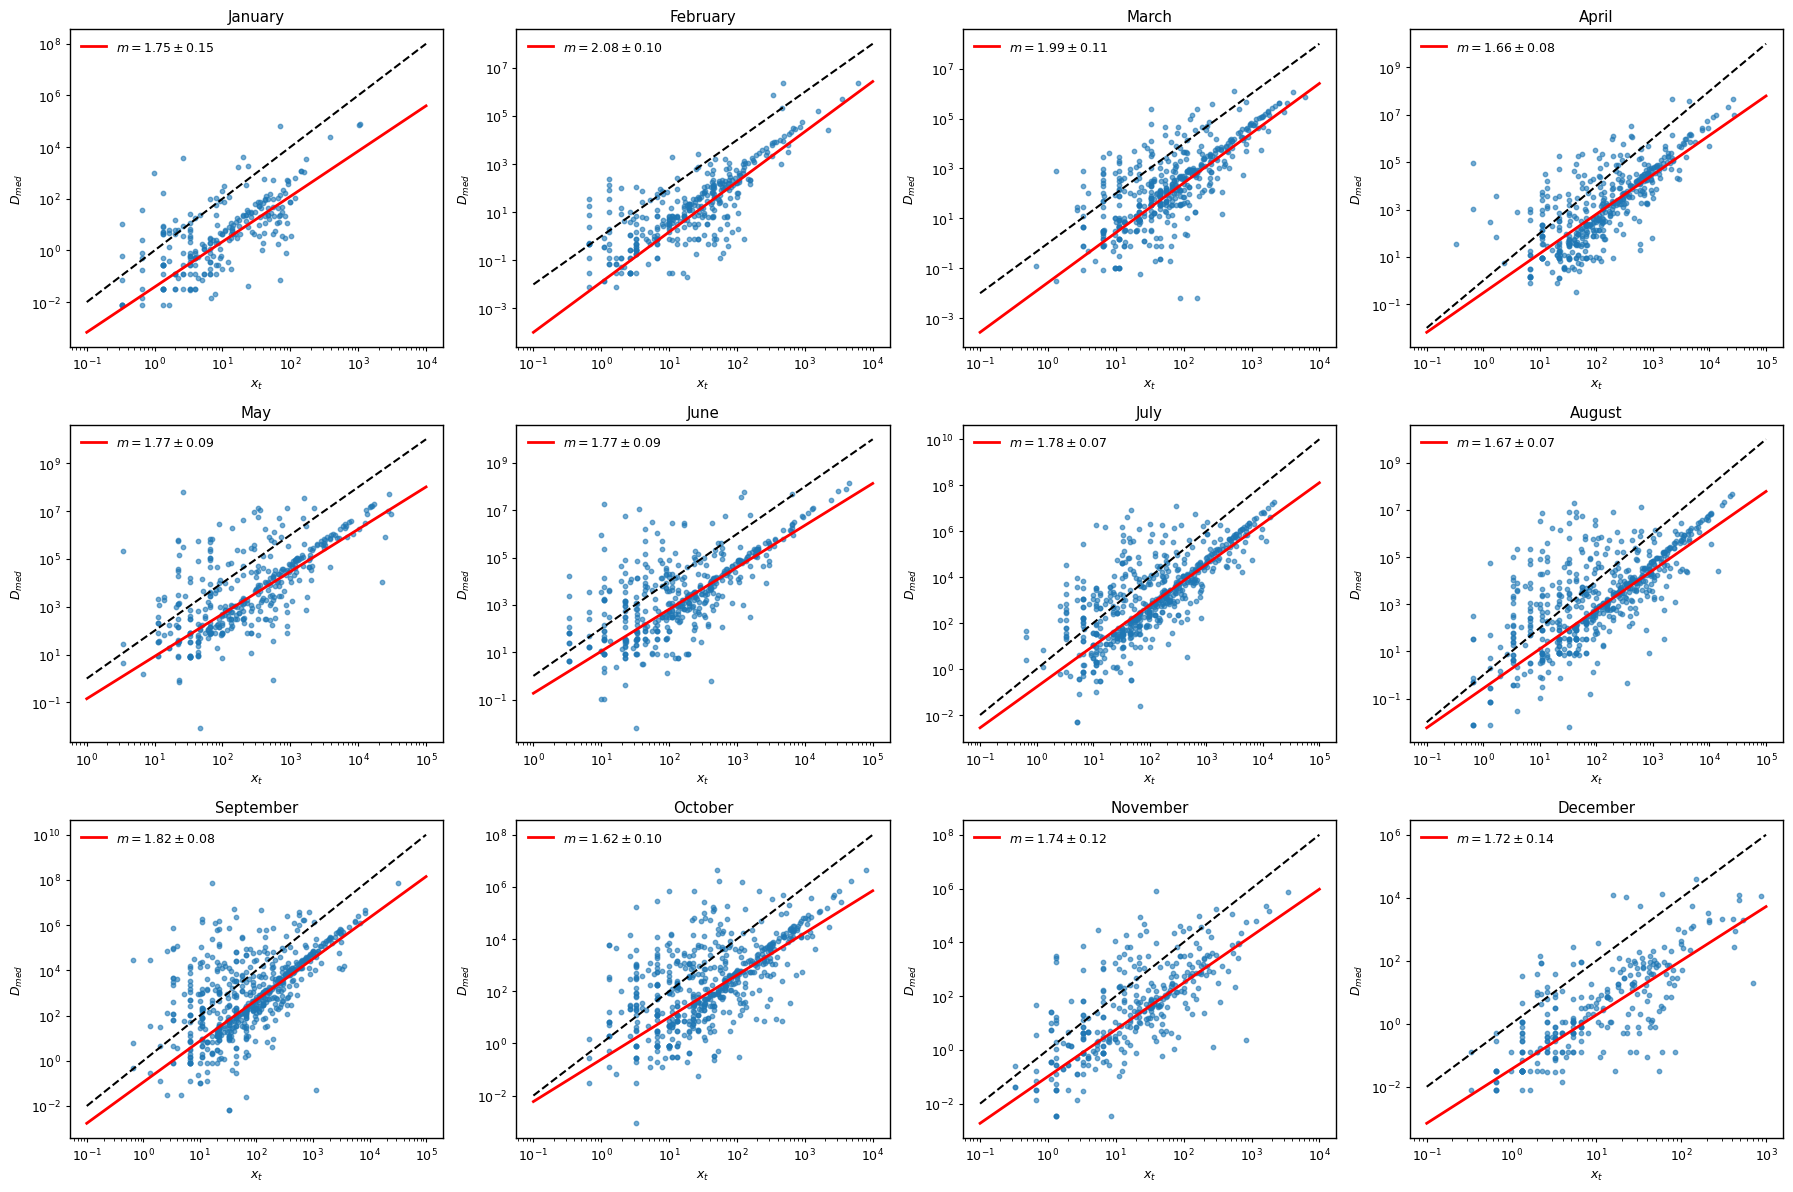

In [17]:
# FOCAL SPECIES NOISE

plt.figure(figsize=(18, 12))

for m in range(1, 13):
    mask_month = months == m
    
    species_mask = np.isin(groups_labels, [1, 2, 3])
    subset_species = species_matrix.loc[species_mask, mask_month].to_numpy()
    
    if subset_species.shape[1] < 2:
        continue
    
    x_prev = subset_species[:, :-1]
    x_t = subset_species[:, 1:]
    
    # temporal filter: delay between 5 and 9 days
    delta_t = (dates[mask_month][1:].to_numpy() - dates[mask_month][:-1].to_numpy()).astype('timedelta64[D]').astype(int)
    valid_time_mask = (delta_t >= 5) & (delta_t <= 9)
    
    x_prev = x_prev[:, valid_time_mask]
    x_t = x_t[:, valid_time_mask]
    

    mask_pos = (x_prev > 0) & (x_t > 0)
    x_prev = x_prev * mask_pos
    x_t = x_t * mask_pos
    

    x_prev_flat = x_prev.flatten()
    x_t_flat = x_t.flatten()
    
    mask_flat = (x_prev_flat > 0) & (x_t_flat > 0)
    x_prev_flat = x_prev_flat[mask_flat]
    x_t_flat = x_t_flat[mask_flat]
    

    D_med = (x_t_flat - x_prev_flat)**2 / (2*tau)
    
    mask_plot = (D_med > 1e-6)
    x_plot = x_t_flat[mask_plot]
    y_plot = D_med[mask_plot]
    
    # plot scatter points
    plt.subplot(3, 4, m)
    plt.scatter(x_plot, y_plot, s=10, alpha=0.6)
    
    # mode values
    if len(x_plot) >= 2:
        unique_x = np.unique(x_plot)
        x_mode = []
        y_mode = []
        for val in unique_x:
            idx = x_plot == val
            if np.any(idx):
                x_mode.append(val)
                y_mode.append(mode(y_plot[idx], keepdims=False).mode)
        x_mode = np.array(x_mode)
        y_mode = np.array(y_mode)

        # log-log fit
        log_x = np.log10(x_mode)
        log_y = np.log10(y_mode)
        p, cov = np.polyfit(log_x, log_y, 1, cov=True)
        slope = p[0]
        intercept = p[1]
        slope_err = np.sqrt(cov[0, 0])

        x_fit = np.logspace(np.floor(np.log10(x_mode.min())), np.ceil(np.log10(x_mode.max())), 100)
        y_fit = 10**intercept * x_fit**slope
        
        # Fitted slopes
        plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=fr"$m = {slope:.2f} \pm {slope_err:.2f}$") 

        y_ref = x_fit**2
        plt.plot(x_fit, y_ref, 'k--')  
 
        plt.legend(loc='upper left', frameon=False, fontsize=9)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$x_t$')
    plt.ylabel(r'$D_{med}$')
    plt.title(f'{month_names[m-1]}')

plt.tight_layout()
plt.show()

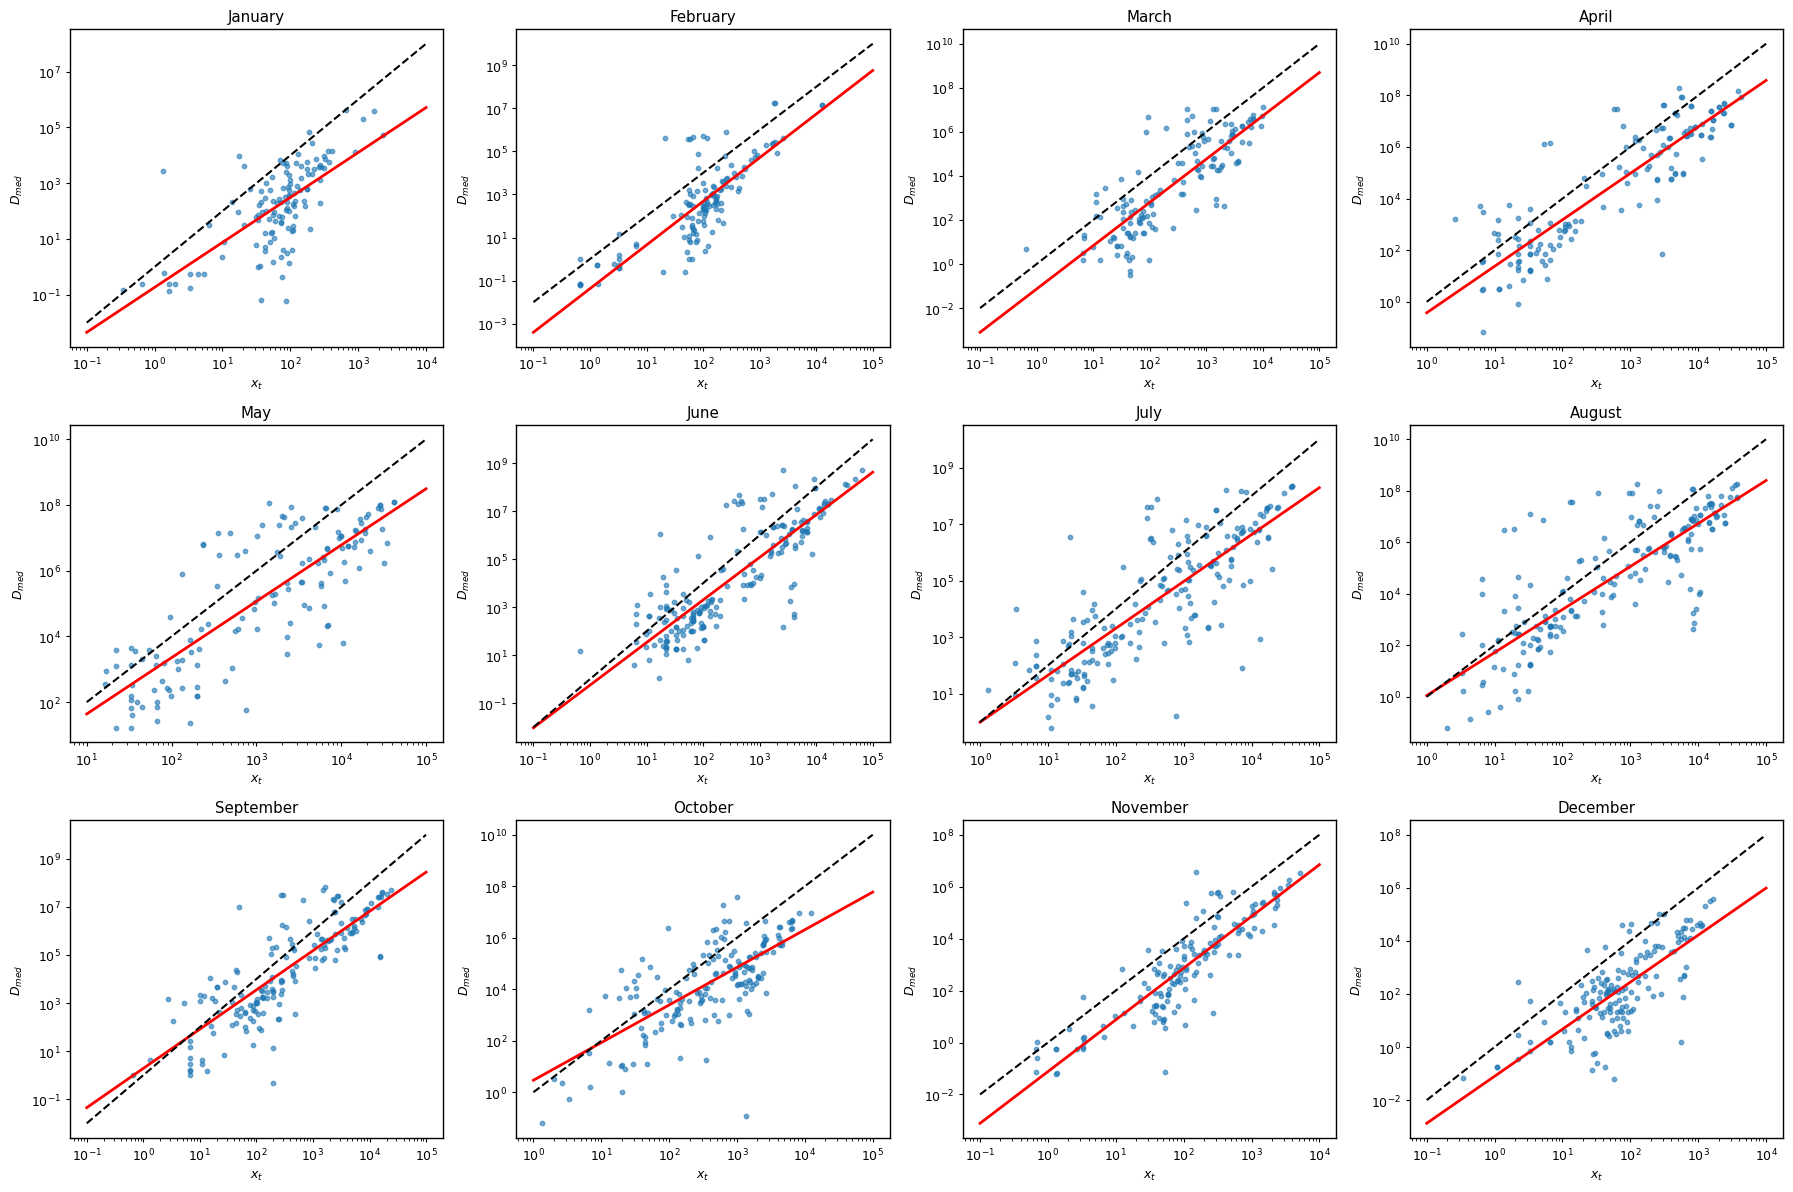

In [18]:
# NOISE TERM TAD

plt.figure(figsize=(18, 12))

for m in range(1, 13):
    mask_month = months == m
    subset_all = df_groups.iloc[:, mask_month].to_numpy()
    
    if subset_all.shape[1] < 2:
        continue
    
    x_prev = subset_all[:, :-1].flatten()
    x_t = subset_all[:, 1:].flatten()
    
    # temporal filter: delay between 5 and 9 days
    delta_t = (dates[mask_month][1:].to_numpy() - dates[mask_month][:-1].to_numpy()).astype('timedelta64[D]').astype(int)
    valid_time_mask = (delta_t >= 5) & (delta_t <= 8)
    
    x_prev = x_prev[valid_time_mask.repeat(subset_all.shape[0])]
    x_t = x_t[valid_time_mask.repeat(subset_all.shape[0])]
    

    mask_pos = (x_prev > 0) & (x_t > 0)
    x_prev = x_prev[mask_pos]
    x_t = x_t[mask_pos]
    

    D_med = (x_t - x_prev)**2 / (tau)
    eps_abs = 0.5
    mask_plot = D_med > eps_abs**2 / (tau)
    x_plot = x_t[mask_plot]
    y_plot = D_med[mask_plot]


    plt.subplot(3, 4, m)
    plt.scatter(x_plot, y_plot, s=10, alpha=0.6)
    
    if len(x_plot) >= 2:
        unique_x = np.unique(x_plot)
        x_mode = []
        y_mode = []
        for val in unique_x:
            idx = x_plot == val
            if np.any(idx):
                x_mode.append(val)
                y_mode.append(mode(y_plot[idx], keepdims=False).mode)
        x_mode = np.array(x_mode)
        y_mode = np.array(y_mode)

        log_x = np.log10(x_mode)
        log_y = np.log10(y_mode)
        slope, intercept = np.polyfit(log_x, log_y, 1)

        x_fit = np.logspace(np.floor(np.log10(x_mode.min())), np.ceil(np.log10(x_mode.max())), 100)
        y_fit = 10**intercept * x_fit**slope
        plt.plot(x_fit, y_fit, 'r-', linewidth=2)  

        
        y_ref = x_fit**2
        plt.plot(x_fit, y_ref, 'k--')  
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$x_t$')
    plt.ylabel(r'$D_{med}$')
    plt.title(f'{month_names[m-1]}')

plt.tight_layout()
plt.show()

In [19]:
b0_TAD = np.full((3, n_months), np.nan)
c_TAD   = np.full((3, n_months), np.nan)
mu_TAD  = np.full((3, n_months), np.nan)
b0_SAD = np.full((3, n_months), np.nan)
c_SAD   = np.full((3, n_months), np.nan)
mu_SAD  = np.full((3, n_months), np.nan)


intercept_total_10 = np.full((3, n_months), np.nan)
intercept_total_err = np.full((3, n_months), np.nan)


intercept_species_10 = np.full((3, n_months), np.nan)
intercept_species_err = np.full((3, n_months), np.nan)


bic_SAD_gig = np.full((3, n_months), np.nan)
bic_SAD_lognorm = np.full((3, n_months), np.nan)
bic_TAD_gig = np.full((3, n_months), np.nan)
bic_TAD_lognorm = np.full((3, n_months), np.nan)

lambda_SAD_gig = np.full((3, n_months), np.nan) 
lambda_TAD_gig = np.full((3, n_months), np.nan) 

In [20]:
def Tscale(b0, c, lam):
    b0 = max(b0, 1e-12)
    c  = max(c, 1e-12)
    arg = 4*np.sqrt(b0/c)
    num = kv(2-lam, arg)**2
    den = kv(3-lam, arg) * kv(-1+lam, arg)
    return 1 - num/den

Fit for SAD, TAD and noise

Power-law slopes lambda:

In [21]:
n_bins = 10
n_groups = 3
n_species_groups = 3
plot_palette = ["#3E4C65", "#60A982", "#DC851F", "#B0A3D4"]
marker_size = 60


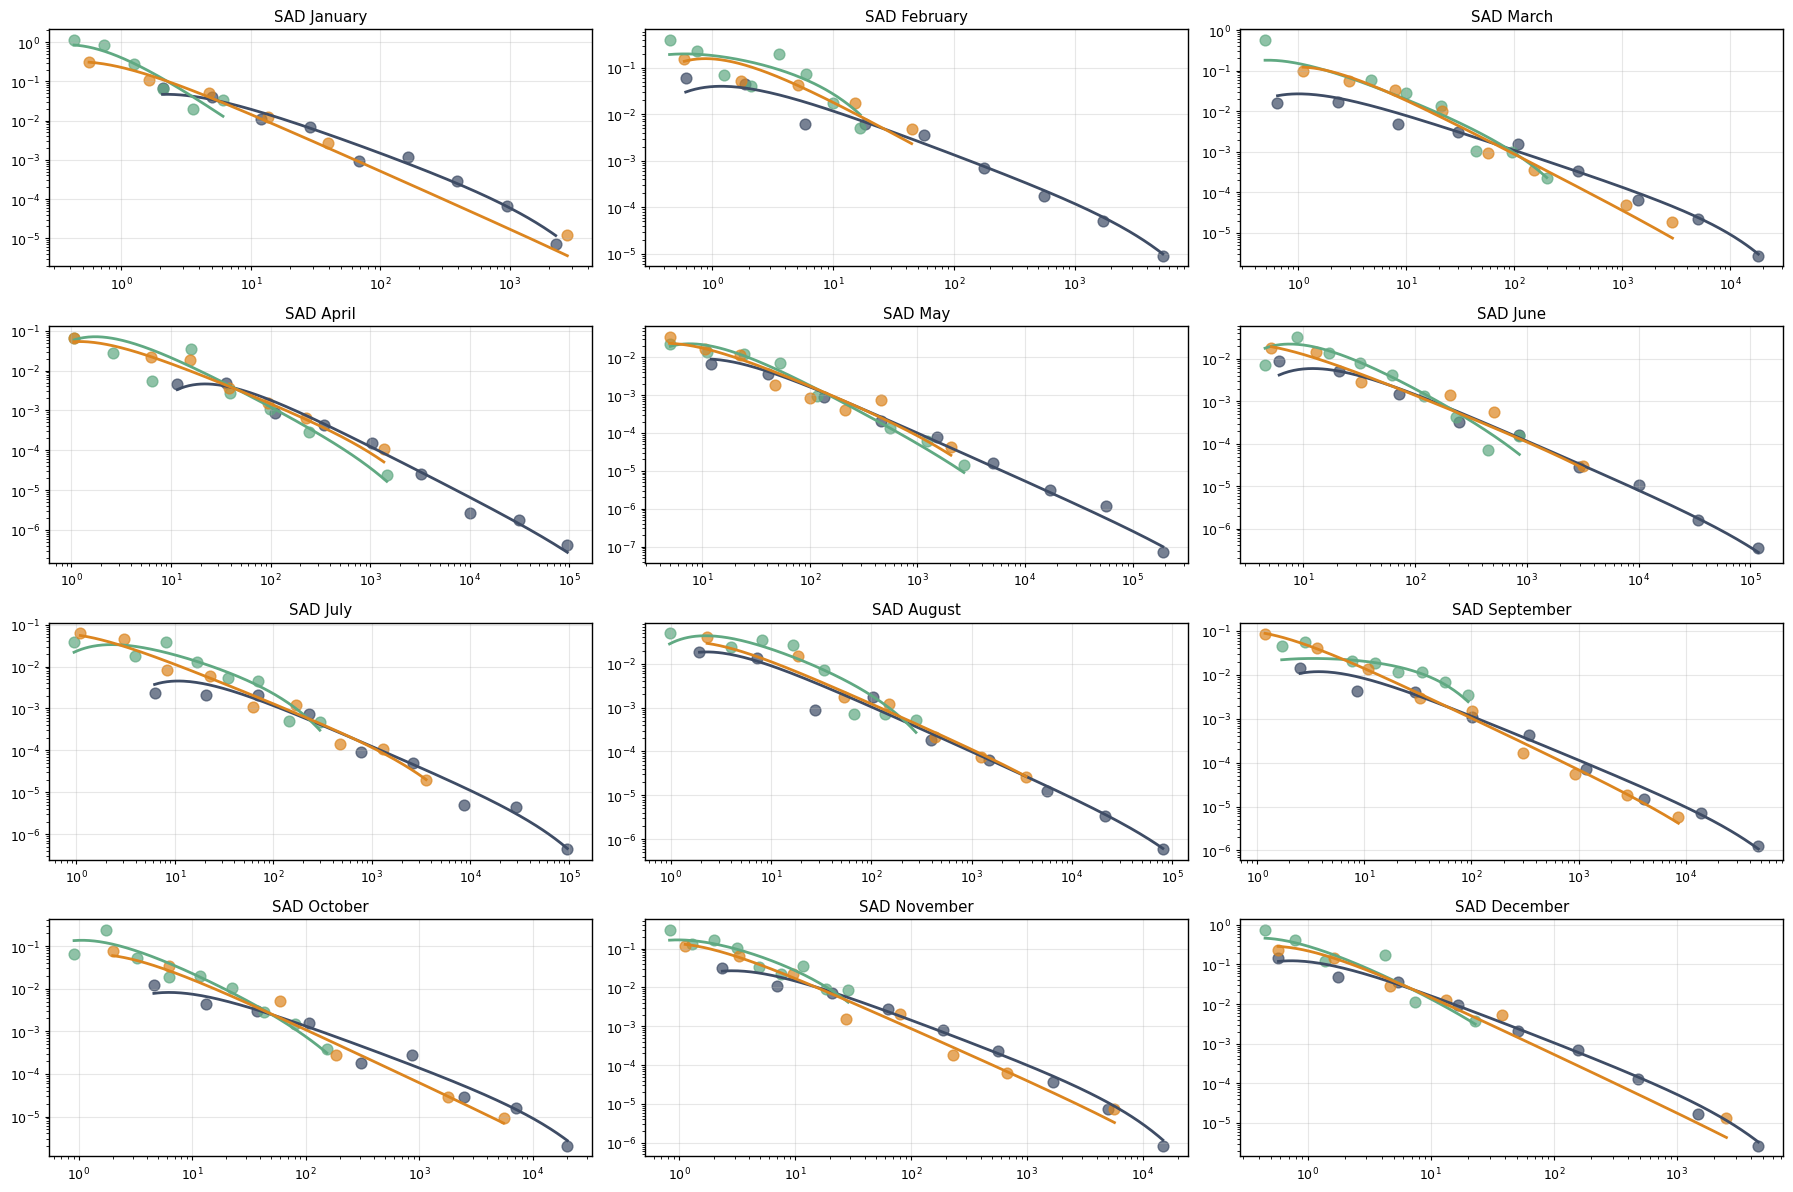

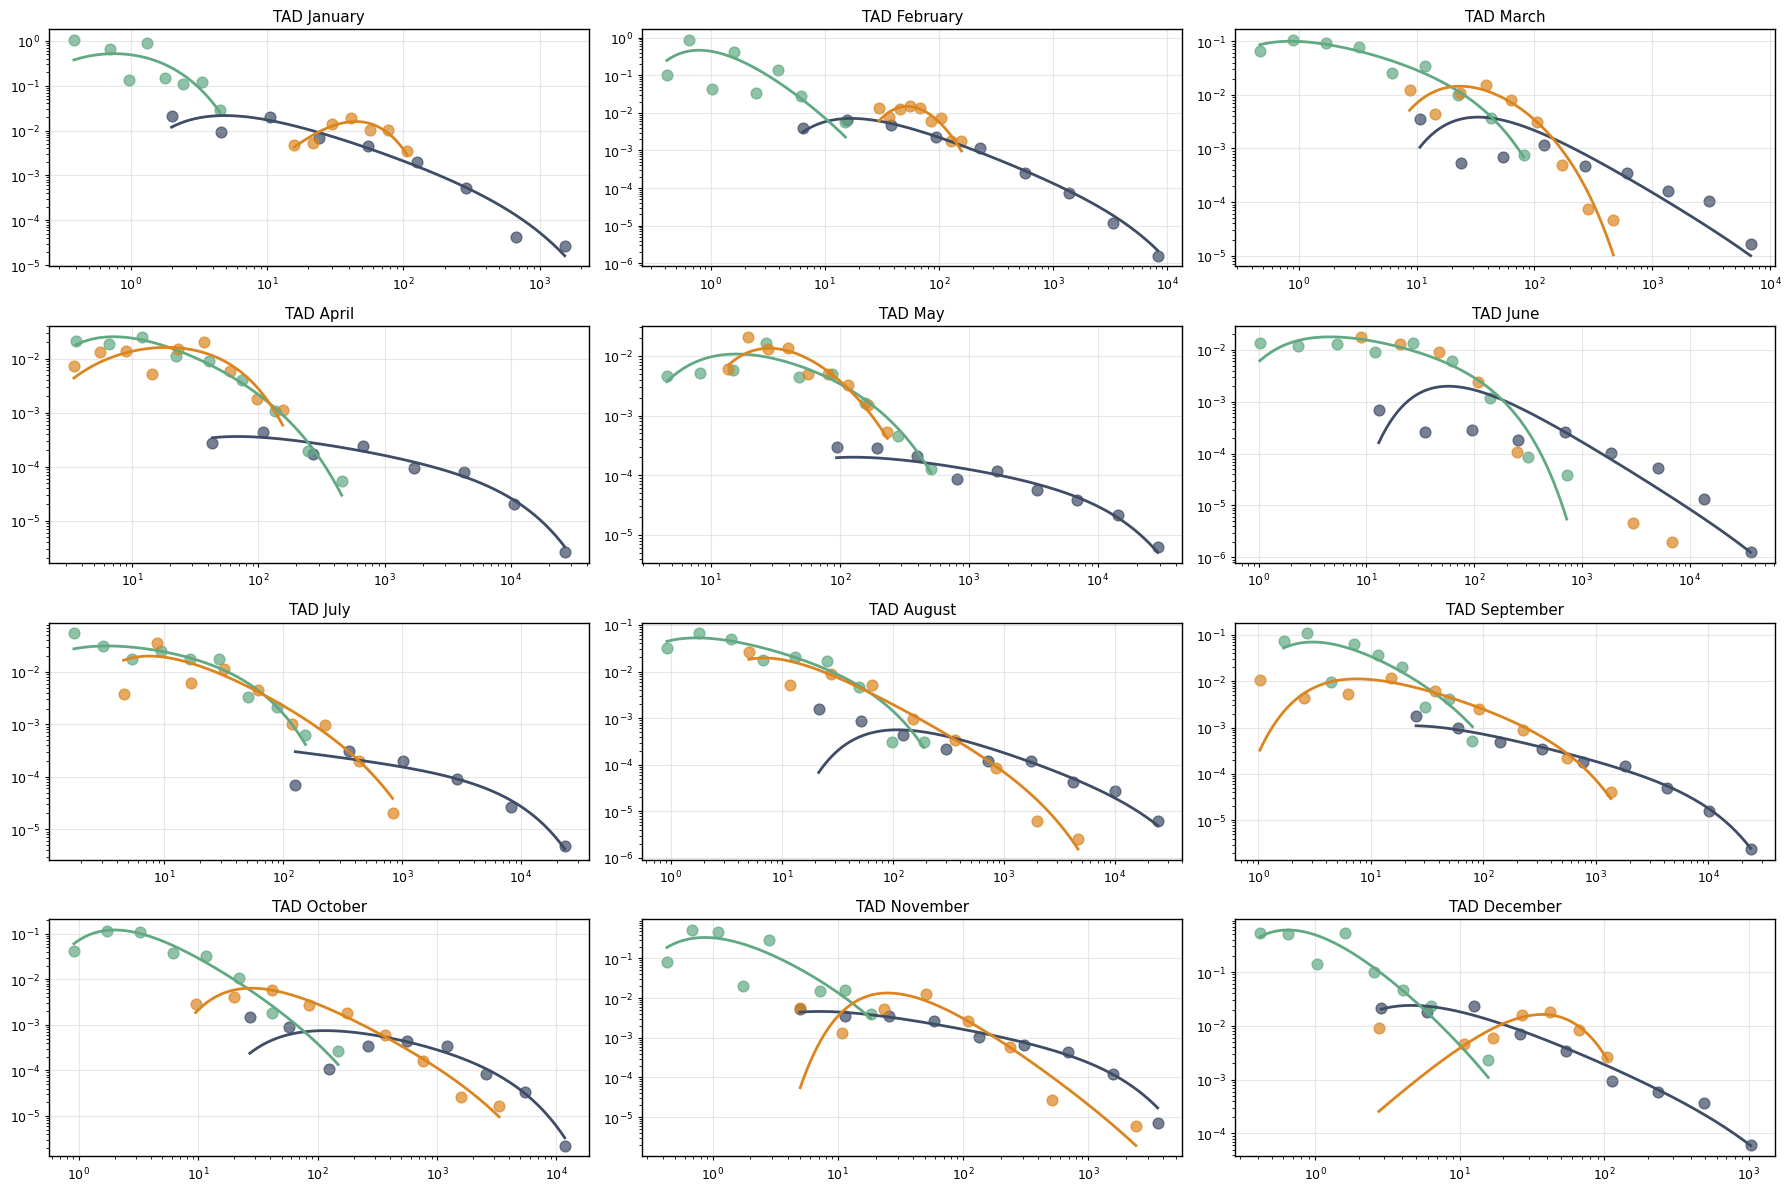

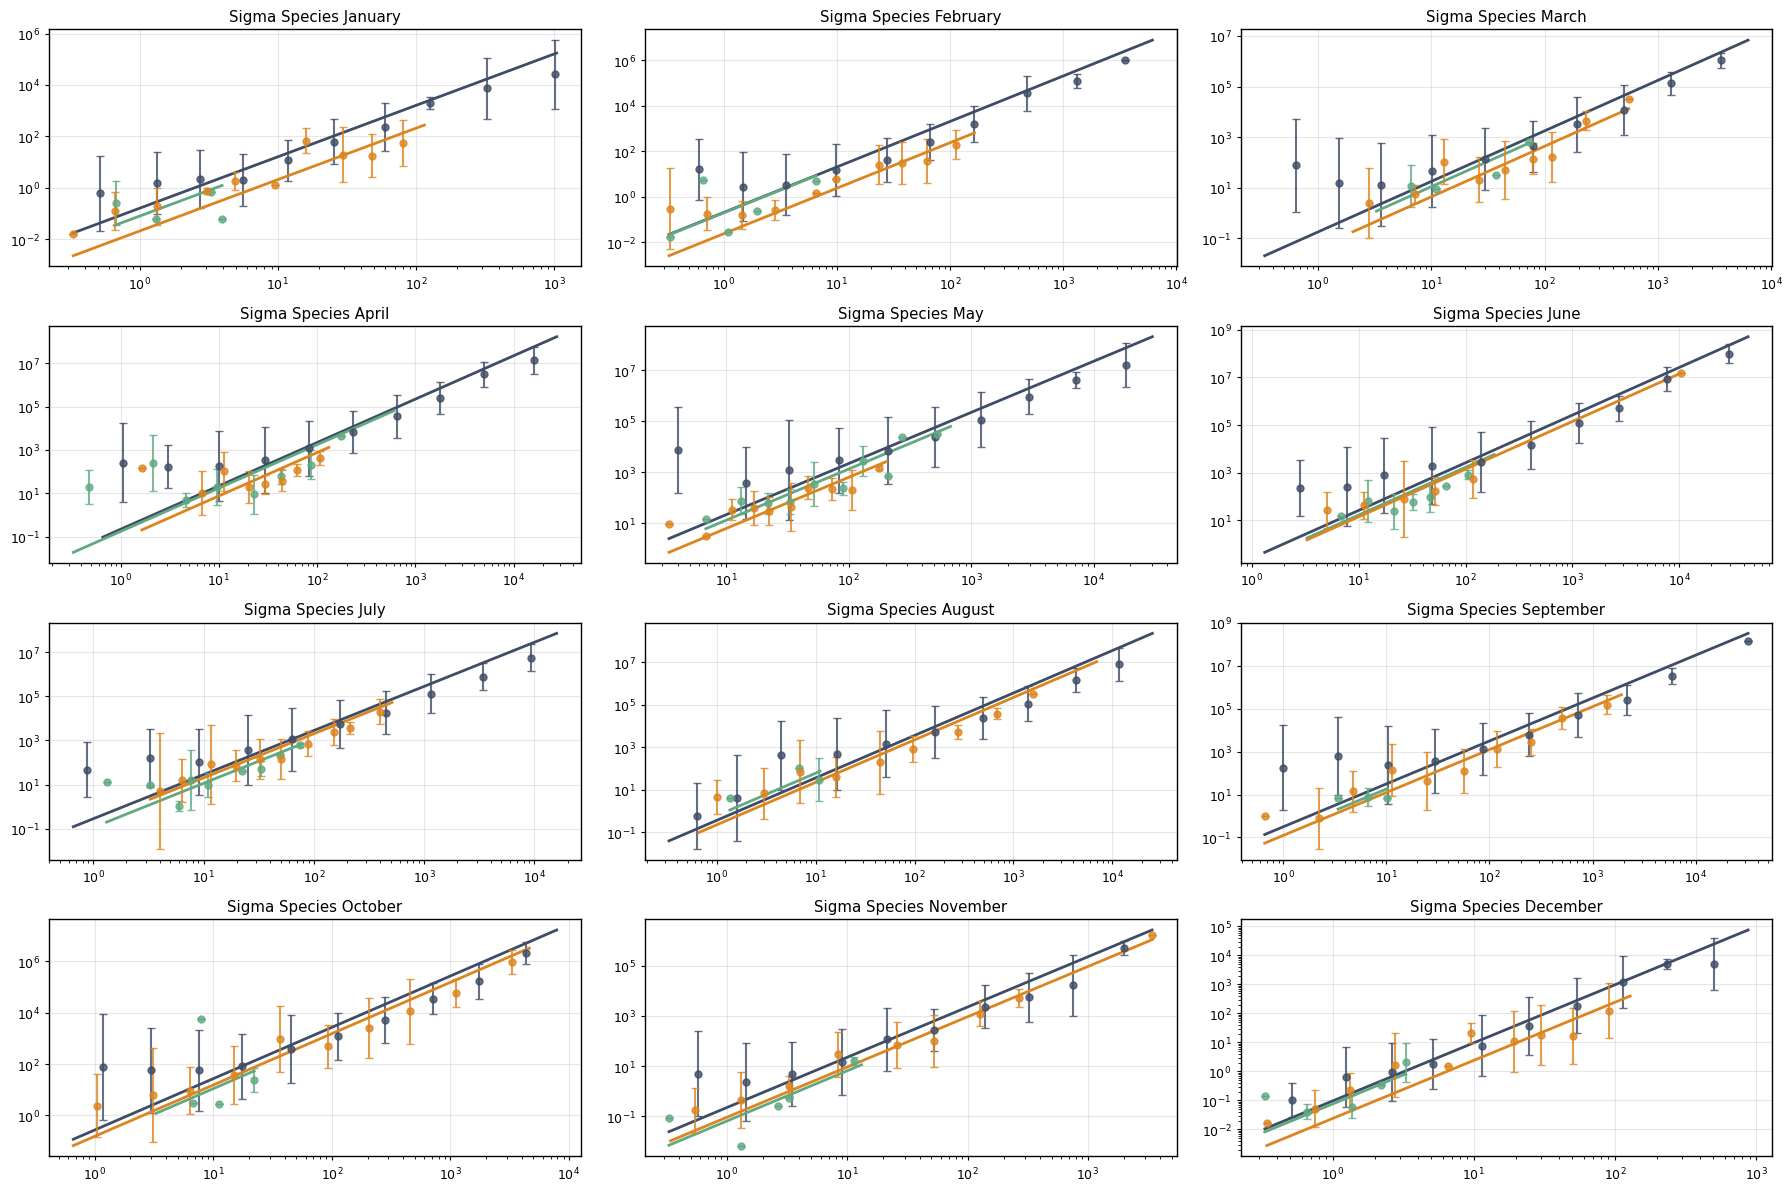

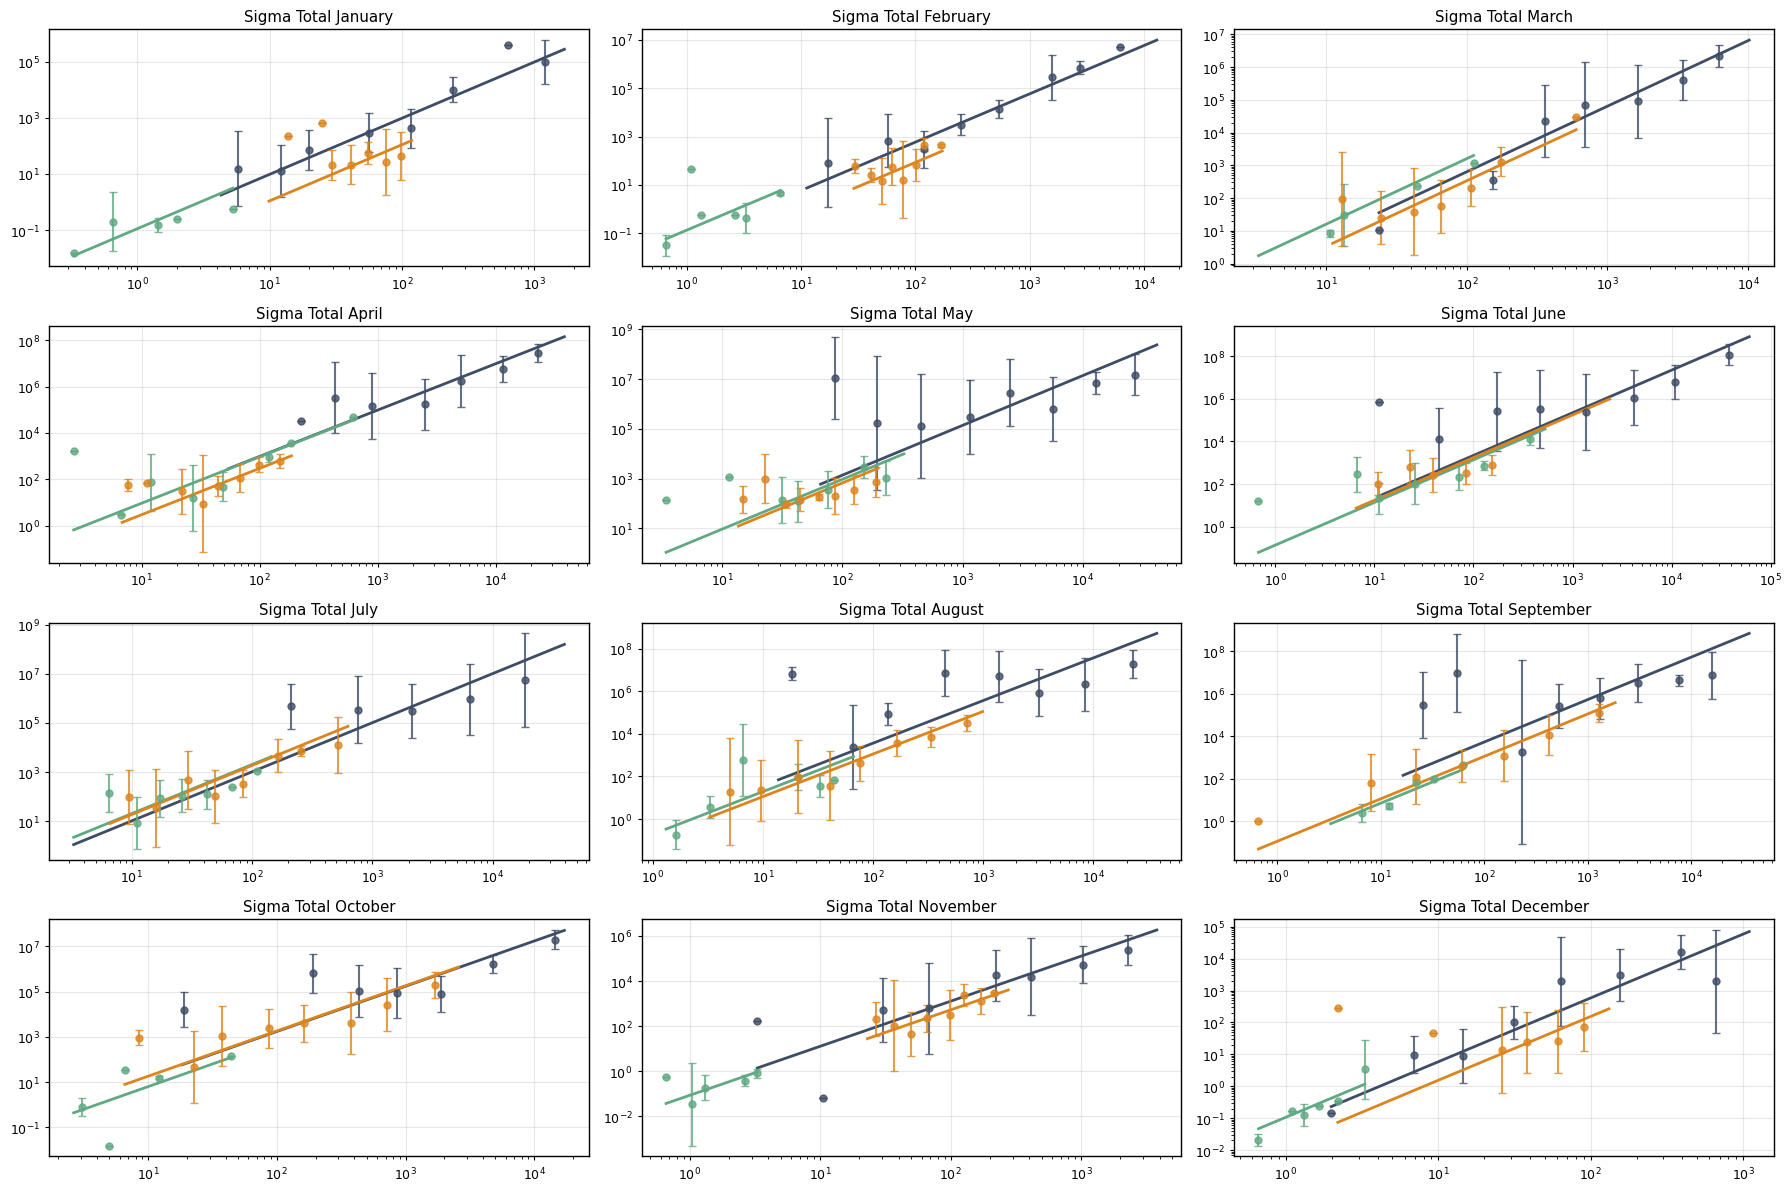

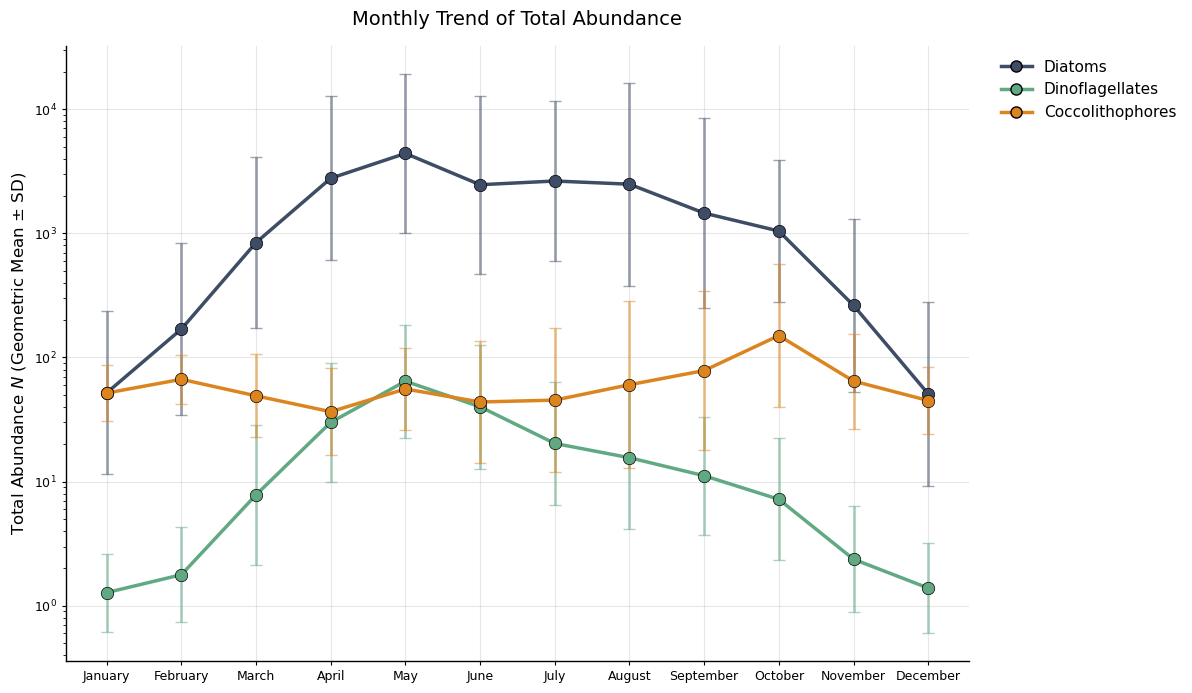

In [22]:
n_rows, n_cols = 4, 3
fig_sad, axes_sad = plt.subplots(n_rows, n_cols, figsize=(18,12))
fig_tad, axes_tad = plt.subplots(n_rows, n_cols, figsize=(18,12))
fig_sigma_sp, axes_sigma_sp = plt.subplots(n_rows, n_cols, figsize=(18,12))
fig_sigma_tot, axes_sigma_tot = plt.subplots(n_rows, n_cols, figsize=(18,12))

plot_points_data = []

geom_means_TAD = np.full((3, 12), np.nan)
geom_low_TAD = np.full((3, 12), np.nan)
geom_high_TAD = np.full((3, 12), np.nan)

for m in range(12):
    mask_month = months == (m+1)

    ax = axes_sad[m//n_cols, m%n_cols]
    for j,g in enumerate(unique_groups):
        if g == 4:
            continue
        species_mask = groups_labels==g

        total_abund = species_matrix.iloc[species_mask, mask_month].sum(axis=1)
        total_abund = total_abund[total_abund>0]
        n_samples = len(total_abund)
        if n_samples >= 3:
            x_vals, y_vals = compute_pdf_log(total_abund, n_bins)
            ax.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])

            for x_val, y_val in zip(x_vals, y_vals):
                plot_points_data.append({
                    'Month_ID': m,
                    'Group_ID': j,
                    'Plot_Type': 'SAD',
                    'x': x_val,
                    'y': y_val,
                    'y_low': np.nan,
                    'y_high': np.nan
                })

            popt, pdf_data, nll = fit_bessel(total_abund, x_vals, y_vals)
            if popt is not None and pdf_data is not None:
                b0_SAD[j,m], c_SAD[j,m], mu_SAD[j,m] = popt
                bic_SAD_gig[j, m] = 3 * np.log(n_samples) + 2 * nll
                ax.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"SAD {month_names[m]}")

    ax = axes_tad[m//n_cols, m%n_cols]
    for j,name in enumerate(group_names):
        if str(name).strip().lower() == 'all':
            continue
            
        vals = df_groups.iloc[j, mask_month].to_numpy()
        vals = vals[vals>0]

        if j < 3 and len(vals) > 0:
            log_vals = np.log10(vals)
            mean_log = np.mean(log_vals)
            
            geom_means_TAD[j, m] = 10**mean_log
            
            if len(vals) > 1:
                std_log = np.std(log_vals, ddof=1)
                geom_low_TAD[j, m] = 10**(mean_log - std_log)
                geom_high_TAD[j, m] = 10**(mean_log + std_log)
            else:
                geom_low_TAD[j, m] = 10**mean_log
                geom_high_TAD[j, m] = 10**mean_log

            plot_points_data.append({
                'Plot_Type': 'Seasonality_TAD',
                'Month_ID': m,
                'Group_ID': j,
                'x': m + 1,
                'y': geom_means_TAD[j, m],
                'y_low': geom_low_TAD[j, m],
                'y_high': geom_high_TAD[j, m]
            })

        n_samples = len(vals)
        if n_samples >= 3:
            x_vals, y_vals = compute_pdf_log(vals, n_bins)
            ax.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])

            for x_val, y_val in zip(x_vals, y_vals):
                plot_points_data.append({
                    'Month_ID': m,
                    'Group_ID': j,
                    'Plot_Type': 'TAD', 
                    'x': x_val,
                    'y': y_val,
                    'y_low': np.nan,
                    'y_high': np.nan
                })

            popt, pdf_data, nll = fit_bessel(vals, x_vals, y_vals)
            if popt is not None and pdf_data is not None:
                b0_TAD[j,m], c_TAD[j,m], mu_TAD[j,m] = popt
                bic_TAD_gig[j, m] = 3 * np.log(n_samples) + 2 * nll
                ax.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"TAD {month_names[m]}")

    ax = axes_sigma_sp[m//n_cols, m%n_cols]
    for j,g in enumerate(unique_groups):
        if g == 4:
            continue
            
        color = plot_palette[j]
        species_mask = groups_labels==g

        subset = species_matrix.iloc[species_mask, mask_month].to_numpy()
        if subset.shape[1]>=2:
            x_prev = subset[:,:-1]
            x_t    = subset[:,1:]
            
            mask_pos = (x_prev>0)&(x_t>0)
            x_prev, x_t = (x_prev*mask_pos).flatten(), (x_t*mask_pos).flatten()
            
            mask_flat = (x_prev>0)&(x_t>0)
            x_prev, x_t = x_prev[mask_flat], x_t[mask_flat]
            
            if len(x_prev)>=3:
                D = (x_t - x_prev)**2/(tau)
                mask = (D > 1e-3)

                x_raw = x_t[mask]
                y_raw = D[mask]
                
                if len(x_raw)>=3:
                    n_bins_sigma = 10 if j == 0 else 10
                    x_c, y_c, y_l, y_h, _ = dynamic_log_binning(x_raw, y_raw, n_bins_sigma)
                    
                    yerr_low = y_c - y_l
                    yerr_high = y_h - y_c
                    ax.errorbar(x_c, y_c, yerr=[yerr_low, yerr_high], fmt='o', color=color, alpha=0.8, ecolor=color, capsize=3, markersize=5)
                    
                    for i in range(len(x_c)):
                        plot_points_data.append({
                            'Month_ID': m,
                            'Group_ID': j,
                            'Plot_Type': 'Sigma_Species', 
                            'x': x_c[i],
                            'y': y_c[i],
                            'y_low': y_l[i],
                            'y_high': y_h[i]
                        })

                    log_y = np.log10(y_raw)
                    log_x = np.log10(x_raw)
                    log_c_vals = log_y - 2*log_x
                    
                    intercept = 10**(np.mean(log_c_vals))
                    intercept_species_10[j,m] = intercept 
                    
                    intercept_err = intercept * np.log(10) * (np.std(log_c_vals, ddof=1) / np.sqrt(len(log_c_vals)))
                    intercept_species_err[j,m] = intercept_err
                    
                    x_fit = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                    y_fit = intercept*x_fit**2
                    ax.plot(x_fit, y_fit, color=color, lw=2)
                    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Sigma Species {month_names[m]}")

    ax = axes_sigma_tot[m//n_cols, m%n_cols]
    for j,name in enumerate(group_names):
        if str(name).strip().lower() == 'all':
            continue
            
        color = plot_palette[j]
        series = df_groups.iloc[j, mask_month].to_numpy()
        
        if len(series)>=3:
            delta_t = (dates[mask_month][1:].to_numpy() - dates[mask_month][:-1].to_numpy()).astype('timedelta64[D]').astype(int)
            valid = (delta_t>=5)&(delta_t<=9)
            x_prev = series[:-1][valid]
            x_t    = series[1:][valid]
            
            mask_pos = (x_prev>0)&(x_t>0)
            x_prev, x_t = x_prev[mask_pos], x_t[mask_pos]
            
            if len(x_prev)>=3:
                D = (x_t-x_prev)**2/(tau)
                mask = (D > 1e-3)

                x_raw = x_t[mask]
                y_raw = D[mask]
                
                if len(x_raw)>=3:
                    n_bins_sigma = 8 if j == 0 else 8
                    x_c, y_c, y_l, y_h, _ = dynamic_log_binning(x_raw, y_raw, n_bins_sigma)

                    yerr_low = y_c - y_l
                    yerr_high = y_h - y_c
                    ax.errorbar(x_c, y_c, yerr=[yerr_low, yerr_high], fmt='o', color=color, alpha=0.8, ecolor=color, capsize=3, markersize=5)
                    
                    for i in range(len(x_c)):
                        plot_points_data.append({
                            'Month_ID': m,
                            'Group_ID': j,
                            'Plot_Type': 'Sigma_Total', 
                            'x': x_c[i],
                            'y': y_c[i],
                            'y_low': y_l[i],
                            'y_high': y_h[i]
                        })

                    log_y = np.log10(y_raw)
                    log_x = np.log10(x_raw)
                    log_c_vals = log_y - 2*log_x
                    
                    intercept = 10**(np.mean(log_c_vals))
                    intercept_total_10[j,m] = intercept
                    
                    intercept_err = intercept * np.log(10) * (np.std(log_c_vals, ddof=1) / np.sqrt(len(log_c_vals)))
                    intercept_total_err[j,m] = intercept_err
                    
                    x_fit = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                    y_fit = intercept*x_fit**2
                    ax.plot(x_fit, y_fit, color=color, lw=2)
                    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Sigma Total {month_names[m]}")

fig_sad.tight_layout()
fig_tad.tight_layout()
fig_sigma_sp.tight_layout()
fig_sigma_tot.tight_layout()


fig_geom, ax_geom = plt.subplots(figsize=(12, 7))
x_months = np.arange(1, 13)

for j in range(3):
    valid = ~np.isnan(geom_means_TAD[j])
    x_plot = x_months[valid]
    geom_plot = geom_means_TAD[j][valid]
    
    yerr_lower = geom_plot - geom_low_TAD[j][valid]
    yerr_upper = geom_high_TAD[j][valid] - geom_plot
    
    color = plot_palette[j]
    
    ax_geom.plot(x_plot, geom_plot, lw=2.5, color=color, zorder=4)
    ax_geom.scatter(x_plot, geom_plot, s=80, color=color, edgecolor='black', linewidth=0.5, zorder=5)
    ax_geom.errorbar(x_plot, geom_plot, yerr=[yerr_lower, yerr_upper], fmt='none', 
                 ecolor=color, alpha=0.5, elinewidth=2, capsize=4, zorder=3)

ax_geom.set_xticks(x_months)
ax_geom.set_xticklabels(month_names)
ax_geom.set_yscale('log')
ax_geom.set_ylabel(r"Total Abundance $N$ (Geometric Mean $\pm$ SD)", fontsize=12)
ax_geom.set_title("Monthly Trend of Total Abundance", fontsize=14, pad=15)
ax_geom.grid(True, alpha=0.3)

ax_geom.spines['top'].set_visible(False)
ax_geom.spines['right'].set_visible(False)

handles_geom = [mlines.Line2D([], [], color=plot_palette[j], marker='o', 
                         linestyle='-', lw=2.5, markersize=8, markeredgecolor='black',
                         label=group_names[j]) for j in range(3)]
ax_geom.legend(handles=handles_geom, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False, fontsize=11)

fig_geom.tight_layout()

plt.show()

Save Sigma values and errors

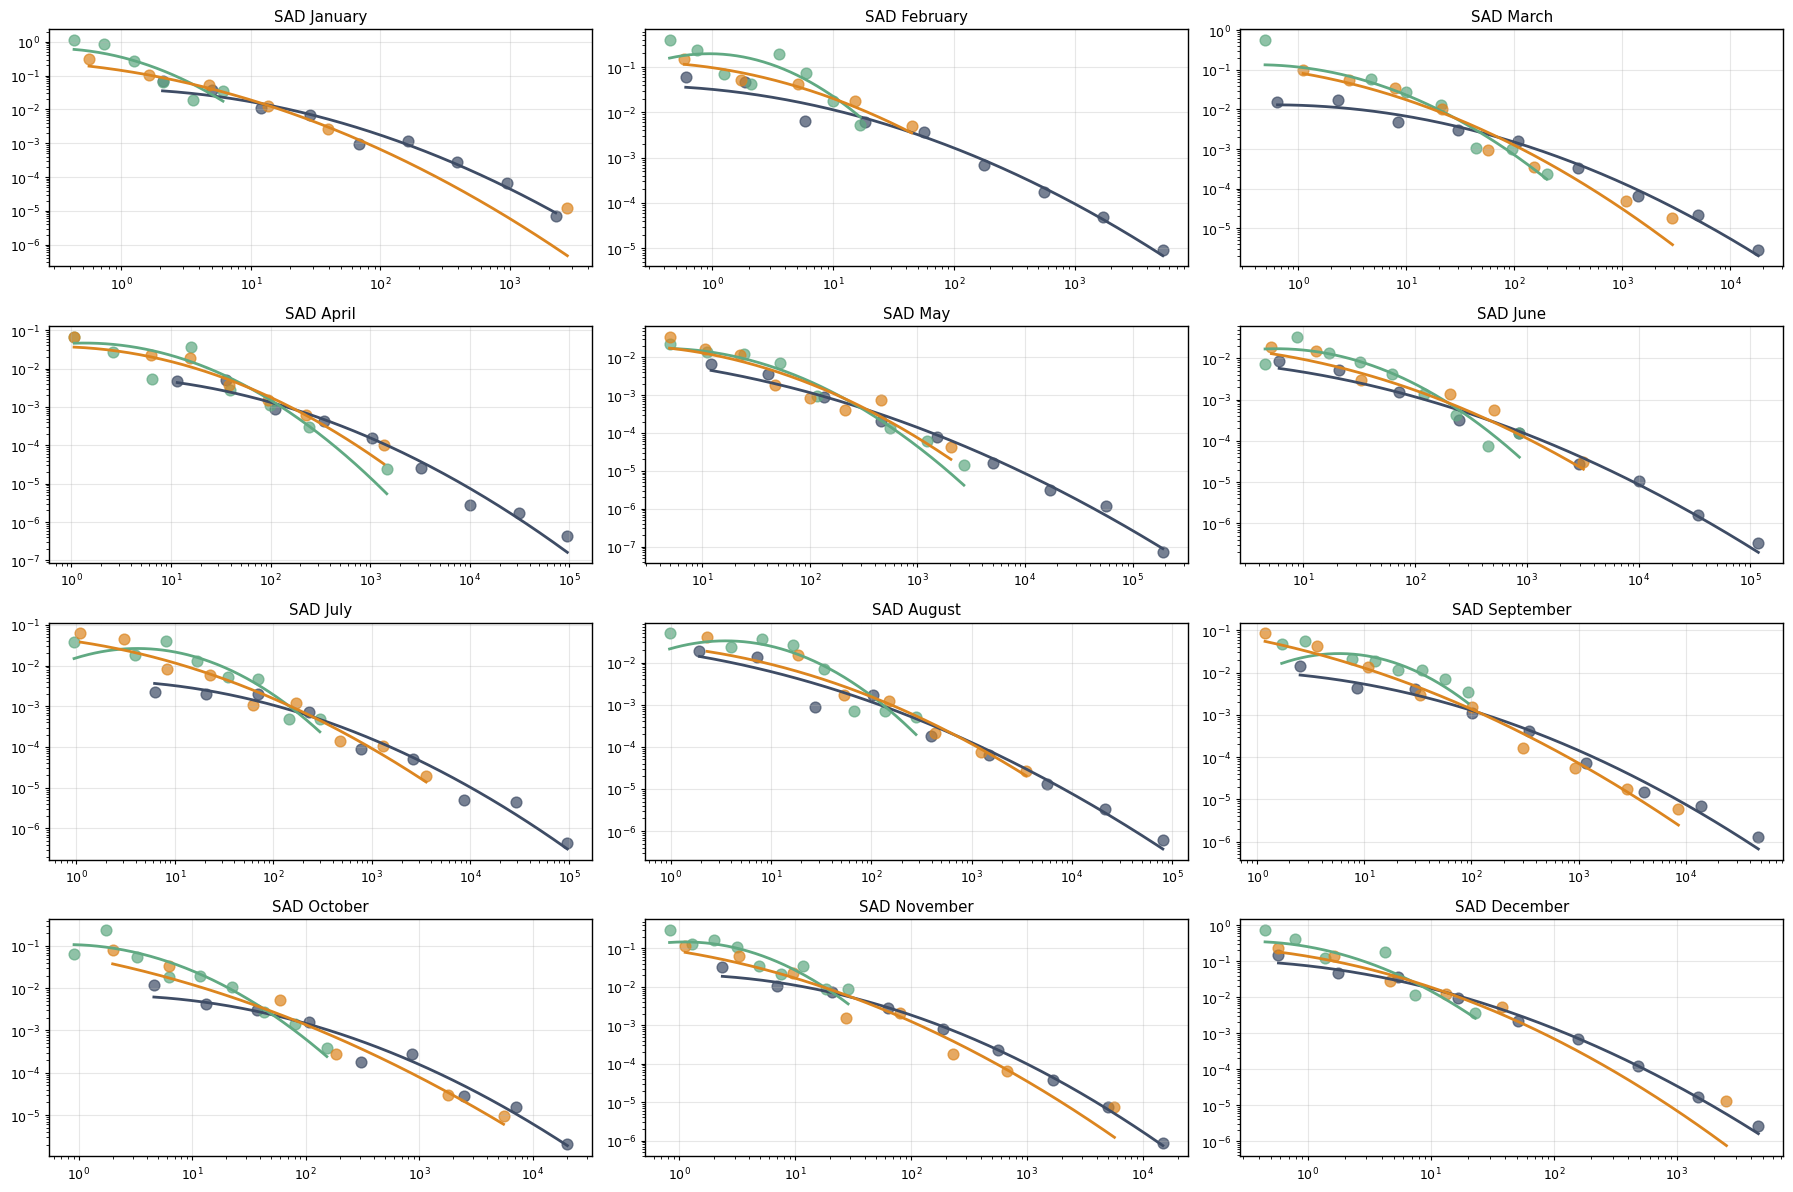

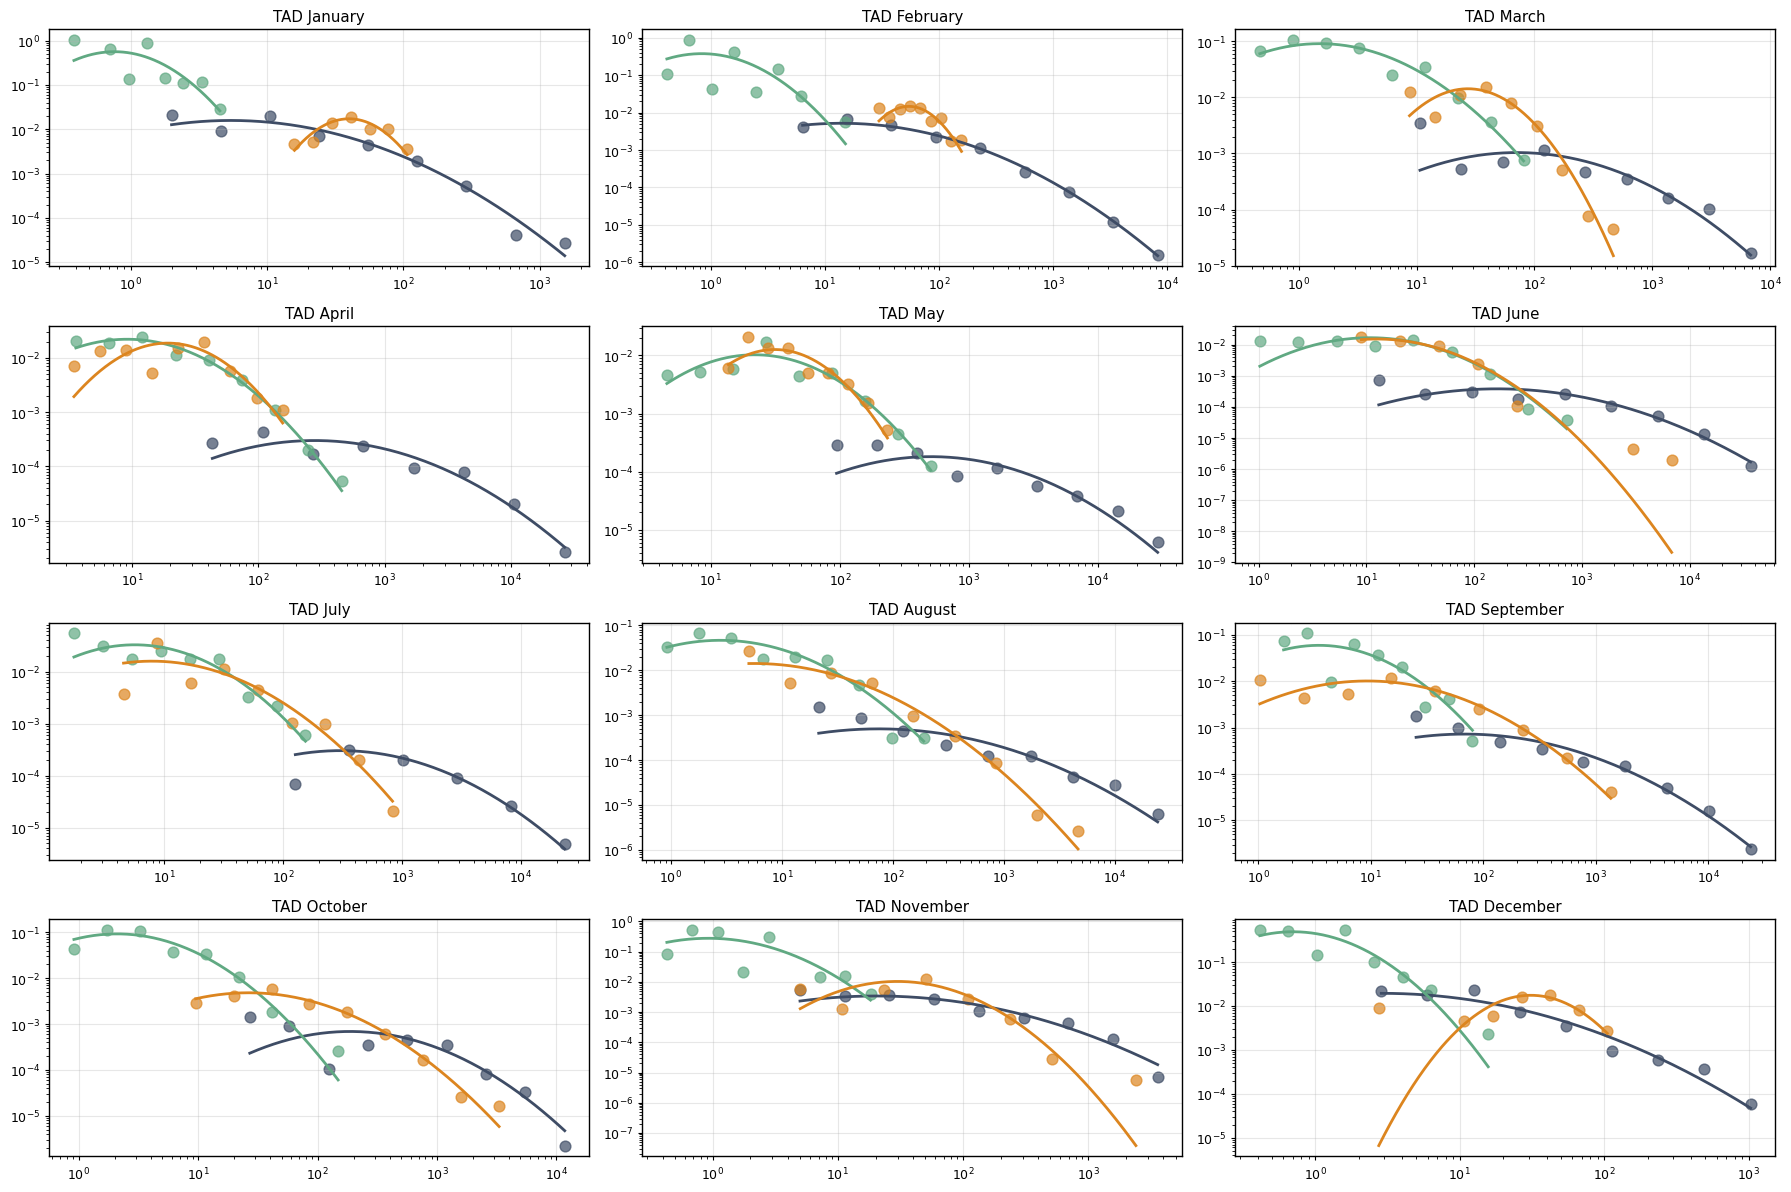

In [26]:
mu_SAD_lognorm    = np.full((n_groups, n_months), np.nan)
sigma_SAD_lognorm = np.full((n_groups, n_months), np.nan)

mu_TAD_lognorm    = np.full((n_groups, n_months), np.nan)
sigma_TAD_lognorm = np.full((n_groups, n_months), np.nan)


n_rows, n_cols = 4, 3
fig_sad, axes_sad = plt.subplots(n_rows, n_cols, figsize=(18, 12))
fig_tad, axes_tad = plt.subplots(n_rows, n_cols, figsize=(18, 12))

marker_size = 60

for m in range(12):
    mask_month = months == (m + 1)

    ax = axes_sad[m // n_cols, m % n_cols]
    for j, g in enumerate(unique_groups):
        if g == 4:
            species_mask = np.isin(groups_labels, base_groups)
        else:
            species_mask = groups_labels == g

        total_abund = species_matrix.iloc[species_mask, mask_month].sum(axis=1)
        total_abund = total_abund[total_abund > 0]
        n_sample = len(total_abund)
        if n_sample >= 3:
            x_vals, y_vals = compute_pdf_log(total_abund, n_bins)
            if len(x_vals) > 0:
                ax.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
                popt, pdf_data, nll = fit_distribution(total_abund, x_vals, y_vals)
                if popt is not None and pdf_data is not None:
                    mu_SAD_lognorm[j, m], sigma_SAD_lognorm[j, m] = popt
                    bic_SAD_lognorm[j,m] = 2*np.log(n_sample) + 2*nll
                    ax.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"SAD {month_names[m]}")

 
    ax = axes_tad[m // n_cols, m % n_cols]
    for j, name in enumerate(group_names):
        vals = df_groups.iloc[j, mask_month].to_numpy()
        vals = vals[vals > 0]
        
        if len(vals) >= 3:
            x_vals, y_vals = compute_pdf_log(vals, n_bins)
            if len(x_vals) > 0:
                ax.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
                popt, pdf_data, nll = fit_distribution(vals, x_vals, y_vals)
                if popt is not None and pdf_data is not None:
                    mu_TAD_lognorm[j, m], sigma_TAD_lognorm[j, m] = popt
                    bic_TAD_lognorm[j,m] = 2*np.log(n_sample) + 2*nll
                    ax.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"TAD {month_names[m]}")


fig_sad.tight_layout()
fig_tad.tight_layout()
plt.show()

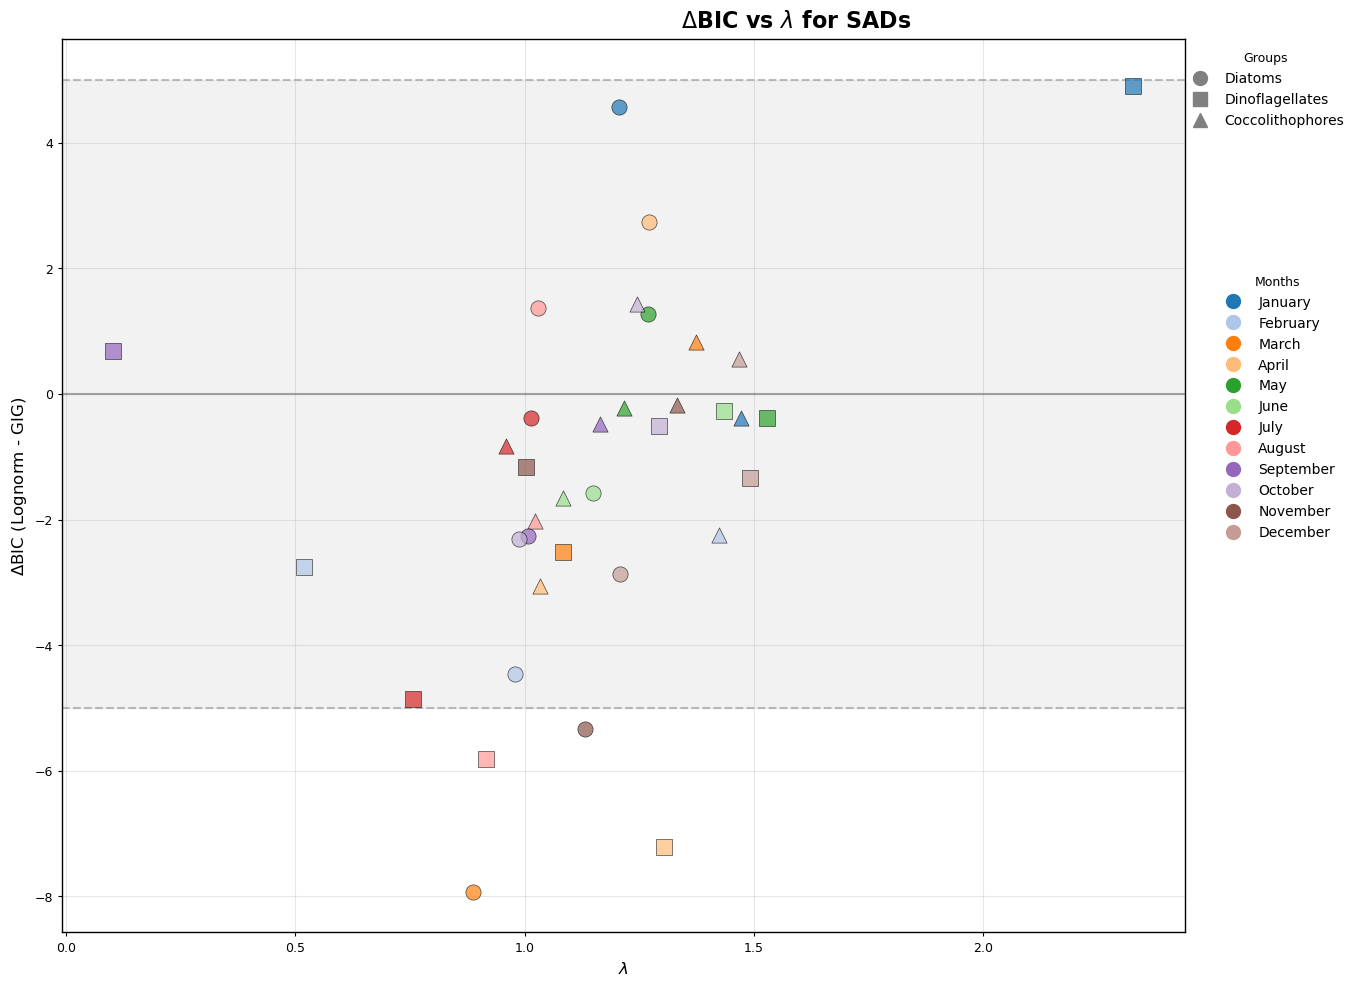

In [27]:
delta_bic_SAD = bic_SAD_lognorm - bic_SAD_gig
lambda_SAD_gig = 2*(1-mu_SAD)

fig_delta, ax_delta = plt.subplots(figsize=(16, 10))
fig_delta.suptitle("$\Delta$BIC vs $\lambda$ for SADs", fontsize=16, fontweight='bold')

group_markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
cmap = plt.colormaps.get_cmap('tab20') if hasattr(plt, 'colormaps') else plt.cm.get_cmap('tab20')
month_colors = [cmap(i) for i in range(12)]

for m in range(12):
    for j in range(n_groups):
        if str(group_names[j]).strip().lower() == 'all':
            continue
            
        x_val = lambda_SAD_gig[j, m]
        y_val = delta_bic_SAD[j, m]
        
        if not np.isnan(x_val) and not np.isnan(y_val):
            marker = group_markers[j % len(group_markers)]
            color = month_colors[m]
            
            marker_size = 120
            alpha_val = 0.7
            z_order = 3

            ax_delta.scatter(x_val, y_val, 
                             color=color, 
                             marker=marker, 
                             s=marker_size, 
                             alpha=alpha_val, 
                             edgecolor='k', 
                             linewidth=0.5,
                             zorder=z_order)

ax_delta.axhspan(-5, 5, color='gray', alpha=0.1, zorder=1)
ax_delta.axhline(5, color='gray', linestyle='--', alpha=0.5, zorder=2)
ax_delta.axhline(0, color='gray', linestyle='-', alpha=0.7, zorder=2)
ax_delta.axhline(-5, color='gray', linestyle='--', alpha=0.5, zorder=2)

ax_delta.set_xlabel("$\lambda$", fontsize=12)
ax_delta.set_ylabel("$\Delta$BIC (Lognorm - GIG)", fontsize=12)
ax_delta.grid(True, alpha=0.3)

handles_groups = [mlines.Line2D([], [], color='gray', marker=group_markers[j % len(group_markers)], 
                                linestyle='None', markersize=10, label=group_names[j]) 
                  for j in range(n_groups) if str(group_names[j]).strip().lower() != 'all']
legend_groups = ax_delta.legend(handles=handles_groups, title="Groups", 
                                loc='upper left', bbox_to_anchor=(0.99, 1), fontsize=10)
ax_delta.add_artist(legend_groups)

handles_months = [mlines.Line2D([], [], color=month_colors[m], marker='o', 
                                linestyle='None', markersize=10, label=month_names[m]) 
                  for m in range(12)]
ax_delta.legend(handles=handles_months, title="Months", 
                loc='upper left', bbox_to_anchor=(1.02, 0.75), fontsize=10)

fig_delta.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

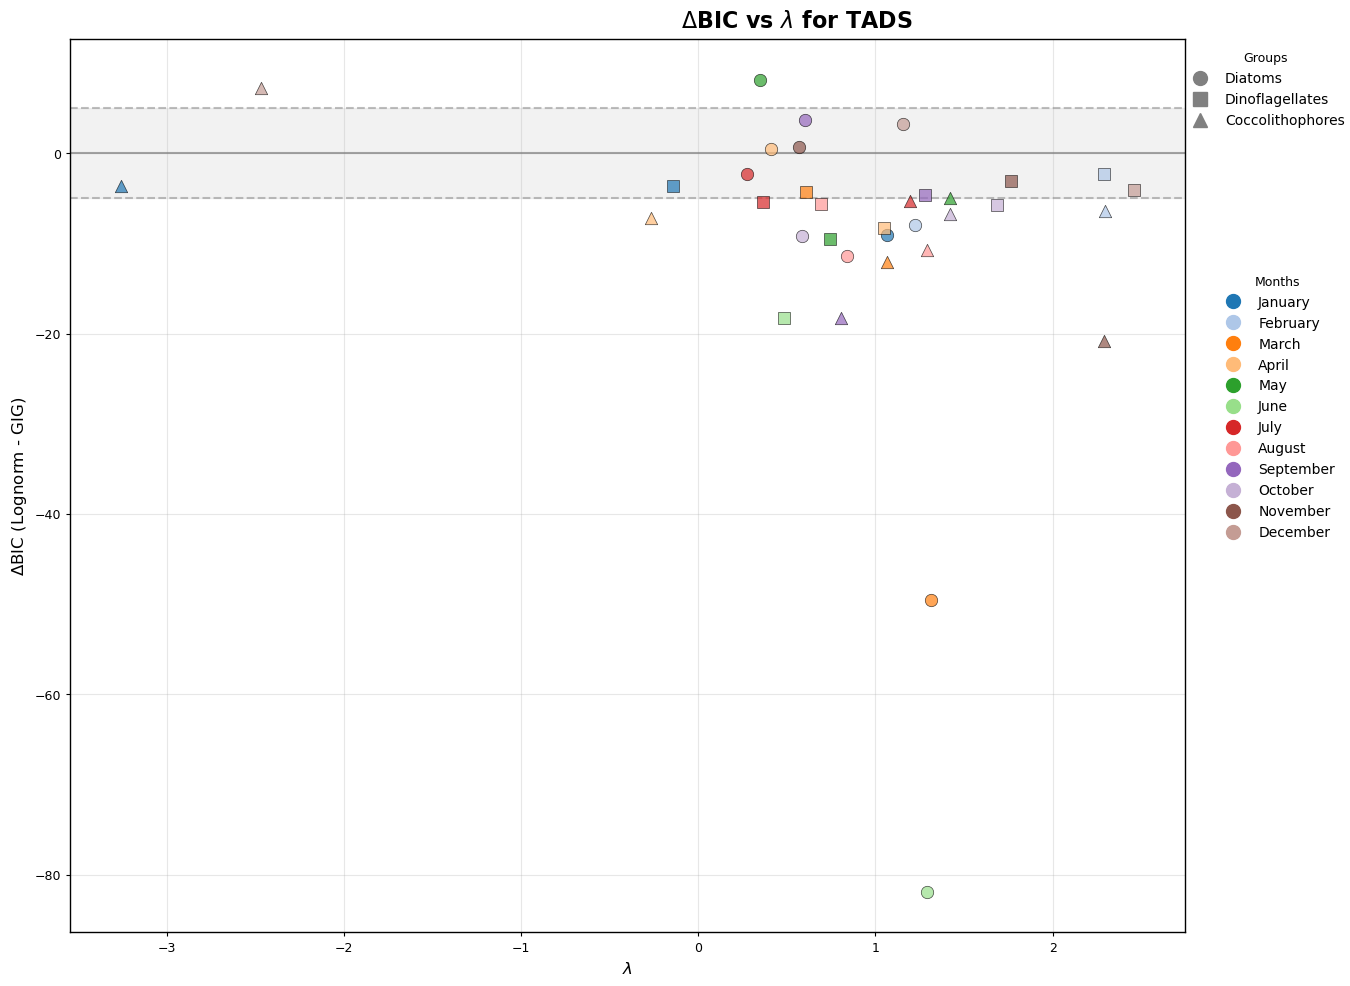

In [28]:
delta_bic_TAD = bic_TAD_lognorm - bic_TAD_gig
lambda_TAD_gig = 2*(1-mu_TAD)

fig_delta, ax_delta = plt.subplots(figsize=(16, 10))
fig_delta.suptitle("$\Delta$BIC vs $\lambda$ for TADS", fontsize=16, fontweight='bold')

group_markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
cmap = plt.colormaps.get_cmap('tab20') if hasattr(plt, 'colormaps') else plt.cm.get_cmap('tab20')
month_colors = [cmap(i) for i in range(12)]

for m in range(12):
    for j in range(n_groups):
        if str(group_names[j]).strip().lower() == 'all':
            continue
            
        x_val = lambda_TAD_gig[j, m]
        y_val = delta_bic_TAD[j, m]
        
        if not np.isnan(x_val) and not np.isnan(y_val):
            marker = group_markers[j % len(group_markers)]
            color = month_colors[m]
            
            marker_size = 80
            alpha_val = 0.7
            z_order = 3

            ax_delta.scatter(x_val, y_val, 
                             color=color, 
                             marker=marker, 
                             s=marker_size, 
                             alpha=alpha_val, 
                             edgecolor='k', 
                             linewidth=0.5,
                             zorder=z_order) 

ax_delta.axhspan(-5, 5, color='gray', alpha=0.1, zorder=1)
ax_delta.axhline(5, color='gray', linestyle='--', alpha=0.5, zorder=2)
ax_delta.axhline(0, color='gray', linestyle='-', alpha=0.7, zorder=2)
ax_delta.axhline(-5, color='gray', linestyle='--', alpha=0.5, zorder=2)

ax_delta.set_xlabel("$\lambda$", fontsize=12)
ax_delta.set_ylabel("$\Delta$BIC (Lognorm - GIG)", fontsize=12)
ax_delta.grid(True, alpha=0.3)

handles_groups = [mlines.Line2D([], [], color='gray', marker=group_markers[j % len(group_markers)], 
                                linestyle='None', markersize=10, label=group_names[j]) 
                  for j in range(n_groups) if str(group_names[j]).strip().lower() != 'all']
legend_groups = ax_delta.legend(handles=handles_groups, title="Groups", 
                                loc='upper left', bbox_to_anchor=(0.99, 1), fontsize=10)
ax_delta.add_artist(legend_groups) 

handles_months = [mlines.Line2D([], [], color=month_colors[m], marker='o', 
                                linestyle='None', markersize=10, label=month_names[m]) 
                  for m in range(12)]
ax_delta.legend(handles=handles_months, title="Months", 
                loc='upper left', bbox_to_anchor=(1.02, 0.75), fontsize=10)

fig_delta.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

Temporal scales

In [30]:
T_SAD = np.array([[Tscale(b0_SAD[j,i], c_SAD[j,i], lambda_SAD_gig[j,i])
                   for i in range(n_months)] for j in range(3)])


T_TAD = np.array([[Tscale(b0_TAD[j,i], c_TAD[j,i], lambda_TAD_gig[j,i])
                   for i in range(n_months)] for j in range(3)])

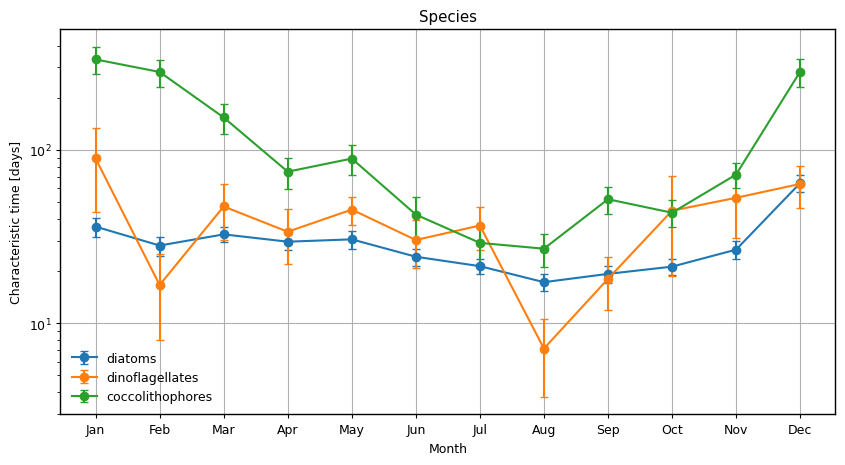

In [31]:
months_numeric = np.arange(1, 13)
month_names_short = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

custom_labels = ["diatoms", "dinoflagellates", "coccolithophores", "All"]


plt.figure(figsize=(10,5))
for j, g in enumerate(unique_groups):
    y = tau * T_SAD[j, :] / intercept_species_10[j, :]
    yerr = tau * T_SAD[j, :] / intercept_species_10[j, :] - tau * T_SAD[j, :] / (intercept_species_10[j, :] + intercept_species_err[j, :])

    plt.errorbar(months_numeric, y,
                 yerr=yerr,
                 fmt='-o', 
                 label=custom_labels[j], 
                 capsize=3)

plt.xticks(months_numeric, month_names_short)
plt.xlabel("Month")
plt.ylabel("Characteristic time [days]")
plt.title("Species")
plt.grid(True)
plt.yscale('log')

plt.legend() 

plt.show()




Full-data

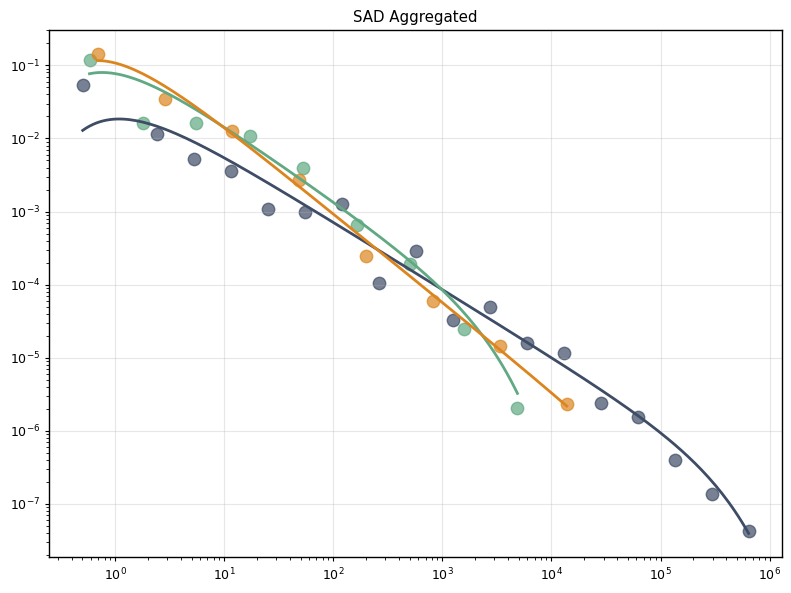

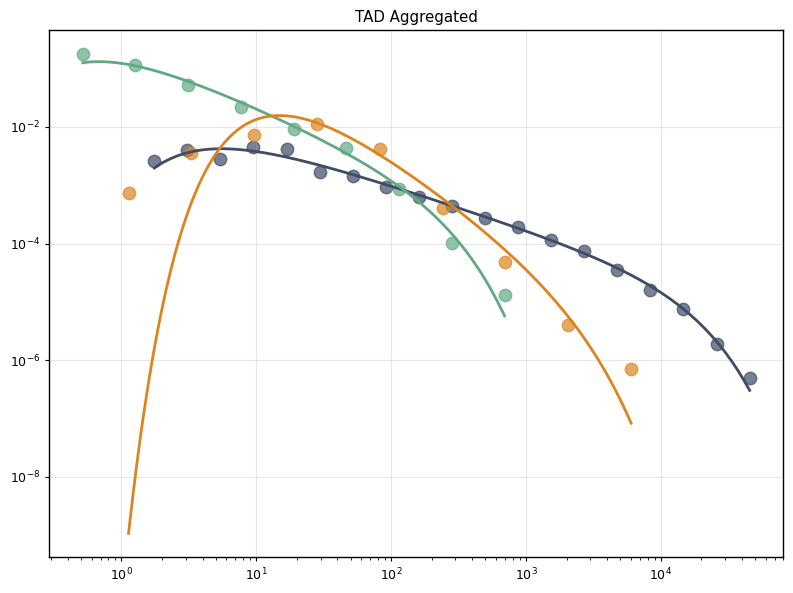

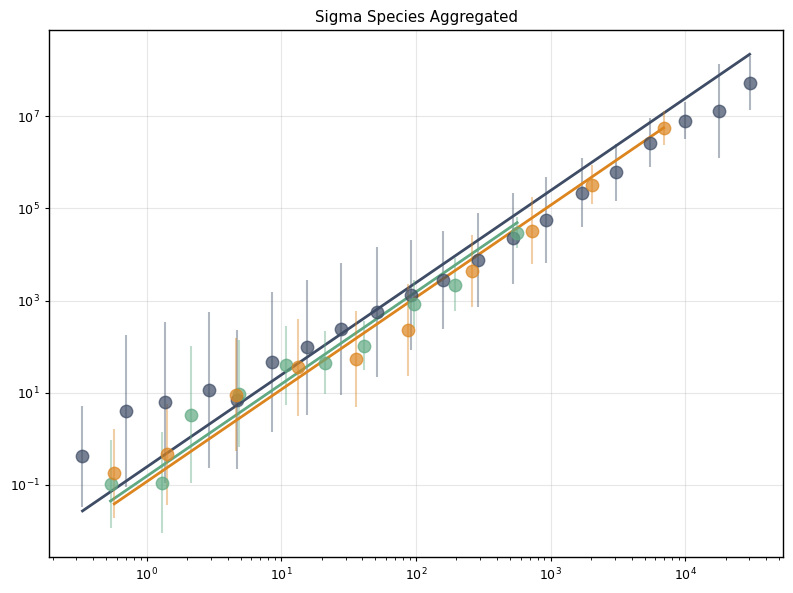

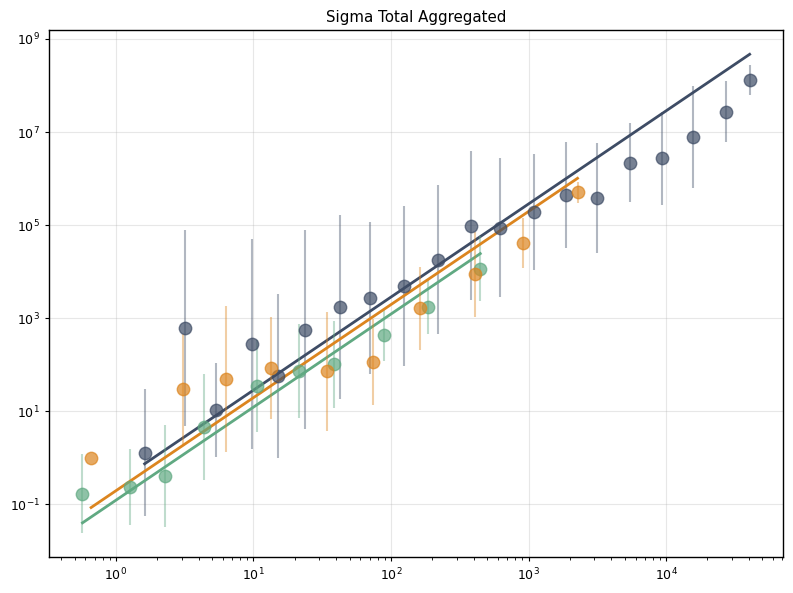

In [33]:

bic_SAD_gig_agg = np.full(3, np.nan)
b0_SAD_agg = np.full(3, np.nan)
c_SAD_agg  = np.full(3, np.nan)
mu_SAD_agg = np.full(3, np.nan)

bic_TAD_gig_agg = np.full(3, np.nan)
b0_TAD_agg = np.full(3, np.nan)
c_TAD_agg  = np.full(3, np.nan)
mu_TAD_agg = np.full(3, np.nan)

intercept_species_10_agg = np.full(len(unique_groups), np.nan)
intercept_species_err_agg = np.full(len(unique_groups), np.nan)

intercept_total_10_agg = np.full(3, np.nan)
intercept_total_err_agg = np.full(3, np.nan)

points_agg_list = []

fig_sad, ax_sad = plt.subplots(figsize=(8, 6))
fig_tad, ax_tad = plt.subplots(figsize=(8, 6))
fig_sigma_sp, ax_sigma_sp = plt.subplots(figsize=(8, 6))
fig_sigma_tot, ax_sigma_tot = plt.subplots(figsize=(8, 6))

for j, g in enumerate(unique_groups):
    if g == 4:
        continue
    
    current_n_bins = 20 if j == 0 else 10
    
    species_mask = groups_labels == g

    total_abund = species_matrix.iloc[species_mask, :].sum(axis=1)
    total_abund = total_abund[total_abund > 0]
    n_samples = len(total_abund)
    if n_samples >= 3:
        x_vals, y_vals = compute_pdf_log(total_abund, current_n_bins)
        
        for i in range(len(x_vals)):
            points_agg_list.append({
                'Plot_Type': 'SAD', 'Month_ID': 'Aggregated', 'Month_Name': 'All Year',
                'Group_ID': j, 'Group_Name': group_names[j],
                'x': x_vals[i], 'y': y_vals[i], 'y_low': np.nan, 'y_high': np.nan
            })
            
        ax_sad.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
        popt, pdf_data, nll = fit_bessel(total_abund, x_vals, y_vals)
        if popt is not None and pdf_data is not None:
            b0_SAD_agg[j], c_SAD_agg[j], mu_SAD_agg[j] = popt
            bic_SAD_gig_agg[j] = 3 * np.log(n_samples) + 2 * nll
            ax_sad.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

ax_sad.set_xscale('log')
ax_sad.set_yscale('log')
ax_sad.grid(True, alpha=0.3)
ax_sad.set_title("SAD Aggregated")

for j, name in enumerate(group_names):
    if str(name).strip().lower() == 'all':
        continue
        
    current_n_bins = 20 if j == 0 else 10
        
    vals = df_groups.iloc[j, :].to_numpy()
    vals = vals[vals > 0]
    n_samples = len(vals)
    if n_samples >= 3:
        x_vals, y_vals = compute_pdf_log(vals, current_n_bins)
        
        for i in range(len(x_vals)):
            points_agg_list.append({
                'Plot_Type': 'TAD', 'Month_ID': 'Aggregated', 'Month_Name': 'All Year',
                'Group_ID': j, 'Group_Name': group_names[j],
                'x': x_vals[i], 'y': y_vals[i], 'y_low': np.nan, 'y_high': np.nan
            })
            
        ax_tad.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
        popt, pdf_data, nll = fit_bessel(vals, x_vals, y_vals)
        if popt is not None and pdf_data is not None:
            b0_TAD_agg[j], c_TAD_agg[j], mu_TAD_agg[j] = popt
            bic_TAD_gig_agg[j] = 3 * np.log(n_samples) + 2 * nll
            ax_tad.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

ax_tad.set_xscale('log')
ax_tad.set_yscale('log')
ax_tad.grid(True, alpha=0.3)
ax_tad.set_title("TAD Aggregated")

for j, g in enumerate(unique_groups):
    if g == 4:
        continue
        
    current_n_bins = 20 if j == 0 else 10
        
    species_mask = groups_labels == g

    subset = species_matrix.iloc[species_mask, :].to_numpy()
    if subset.shape[1] >= 2:
        x_prev = subset[:, :-1]
        x_t = subset[:, 1:]
        mask_pos = (x_prev > 0) & (x_t > 0)
        x_prev, x_t = (x_prev * mask_pos).flatten(), (x_t * mask_pos).flatten()
        mask_flat = (x_prev > 0) & (x_t > 0)
        x_prev, x_t = x_prev[mask_flat], x_t[mask_flat]
        if len(x_prev) >= 5:
            D = (x_t - x_prev)**2 / (tau)
            mask = (D > 1e-3)
            
            x_mean, y_mean, y_low, y_high, _ = dynamic_log_binning(x_t[mask], D[mask], current_n_bins)
            valid = ~np.isnan(y_mean) 
            x_mean, y_mean, y_low, y_high = x_mean[valid], y_mean[valid], y_low[valid], y_high[valid]
            
            if len(x_mean) >= 3:
                for i in range(len(x_mean)):
                    points_agg_list.append({
                        'Plot_Type': 'Sigma_Species', 'Month_ID': 'Aggregated', 'Month_Name': 'All Year',
                        'Group_ID': j, 'Group_Name': group_names[j],
                        'x': x_mean[i], 'y': y_mean[i], 'y_low': y_low[i], 'y_high': y_high[i]
                    })
                    
                yerr = [np.maximum(0, y_mean - y_low), np.maximum(0, y_high - y_mean)]
                ax_sigma_sp.errorbar(x_mean, y_mean, yerr=yerr, fmt='none', ecolor=plot_palette[j], alpha=0.4, elinewidth=1.5)
                ax_sigma_sp.scatter(x_mean, y_mean, color=plot_palette[j], alpha=0.7, s=marker_size, zorder=3)
                
                log_y, log_x = np.log10(y_mean), np.log10(x_mean)
                log_c_vals = log_y - 2 * log_x
                
                intercept = 10**(np.mean(log_c_vals))
                intercept_err = intercept * np.log(10) * (np.std(log_c_vals, ddof=1) / np.sqrt(len(log_c_vals)))
                
                intercept_species_10_agg[j] = intercept
                intercept_species_err_agg[j] = intercept_err
                
                x_fit = np.logspace(np.log10(min(x_mean)), np.log10(max(x_mean)), 200)
                ax_sigma_sp.plot(x_fit, intercept * x_fit**2, color=plot_palette[j], lw=2)

ax_sigma_sp.set_xscale('log')
ax_sigma_sp.set_yscale('log')
ax_sigma_sp.grid(True, alpha=0.3)
ax_sigma_sp.set_title("Sigma Species Aggregated")

for j, name in enumerate(group_names):
    if str(name).strip().lower() == 'all':
        continue
        
    current_n_bins = 20 if j == 0 else 10
        
    series = df_groups.iloc[j, :].to_numpy()
    if len(series) >= 2:
        delta_t = (dates[1:].to_numpy() - dates[:-1].to_numpy()).astype('timedelta64[D]').astype(int)
        valid_dt = (delta_t >= 5) & (delta_t <= 9)
        x_prev = series[:-1][valid_dt]
        x_t = series[1:][valid_dt]
        mask_pos = (x_prev > 0) & (x_t > 0)
        x_prev, x_t = x_prev[mask_pos], x_t[mask_pos]
        if len(x_prev) >= 5:
            D = (x_t - x_prev)**2 / (tau)
            mask = (D > 1e-3)
            
            x_mean, y_mean, y_low, y_high, _ = dynamic_log_binning(x_t[mask], D[mask], current_n_bins)
            valid = ~np.isnan(y_mean)
            x_mean, y_mean, y_low, y_high = x_mean[valid], y_mean[valid], y_low[valid], y_high[valid]
            
            if len(x_mean) >= 3:
                for i in range(len(x_mean)):
                    points_agg_list.append({
                        'Plot_Type': 'Sigma_Total', 'Month_ID': 'Aggregated', 'Month_Name': 'All Year',
                        'Group_ID': j, 'Group_Name': group_names[j],
                        'x': x_mean[i], 'y': y_mean[i], 'y_low': y_low[i], 'y_high': y_high[i]
                    })
                    
                yerr = [np.maximum(0, y_mean - y_low), np.maximum(0, y_high - y_mean)]
                ax_sigma_tot.errorbar(x_mean, y_mean, yerr=yerr, fmt='none', ecolor=plot_palette[j], alpha=0.4, elinewidth=1.5)
                ax_sigma_tot.scatter(x_mean, y_mean, color=plot_palette[j], alpha=0.7, s=marker_size, zorder=3)
                
                log_y, log_x = np.log10(y_mean), np.log10(x_mean)
                log_c_vals = log_y - 2 * log_x
                
                intercept = 10**(np.mean(log_c_vals))
                intercept_err = intercept * np.log(10) * (np.std(log_c_vals, ddof=1) / np.sqrt(len(log_c_vals)))
                
                intercept_total_10_agg[j] = intercept
                intercept_total_err_agg[j] = intercept_err
                
                x_fit = np.logspace(np.log10(min(x_mean)), np.log10(max(x_mean)), 200)
                ax_sigma_tot.plot(x_fit, intercept * x_fit**2, color=plot_palette[j], lw=2)

ax_sigma_tot.set_xscale('log')
ax_sigma_tot.set_yscale('log')
ax_sigma_tot.grid(True, alpha=0.3)
ax_sigma_tot.set_title("Sigma Total Aggregated")

fig_sad.tight_layout()
fig_tad.tight_layout()
fig_sigma_sp.tight_layout()
fig_sigma_tot.tight_layout()
plt.show()

if 'df_points_agg_final' not in locals():
    df_points_agg_final = pd.DataFrame(points_agg_list)

Analysis of slopes + save data

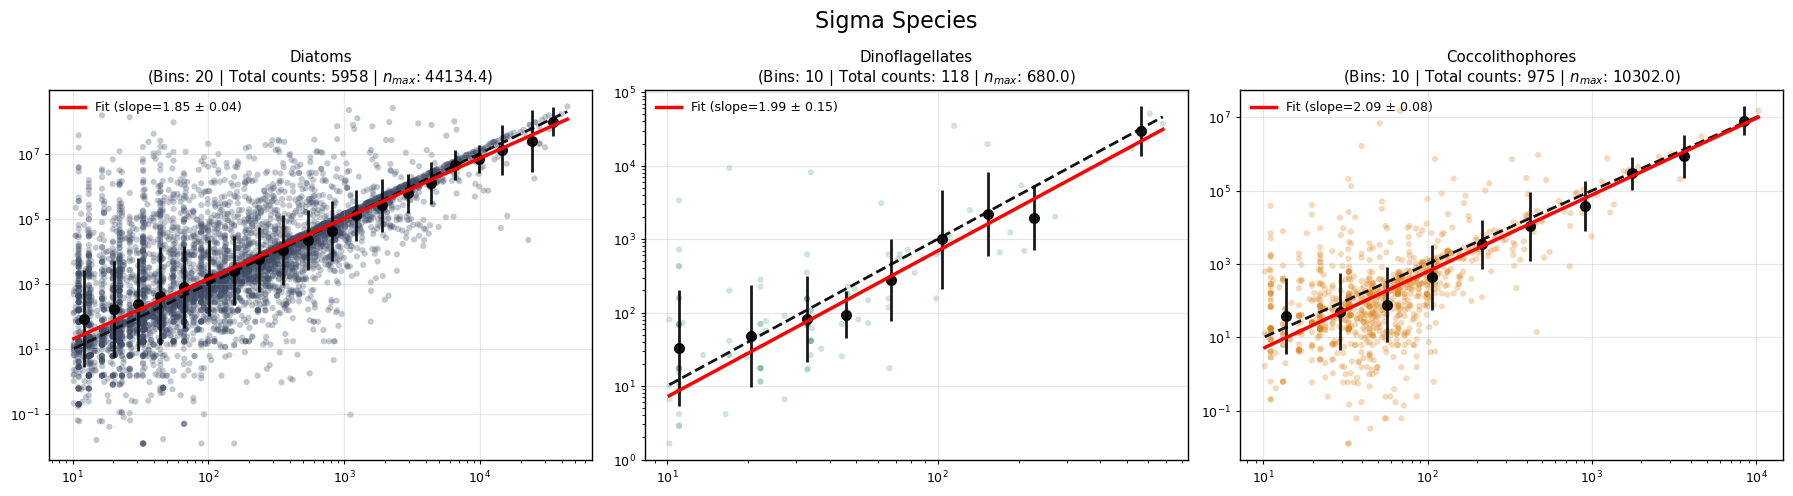

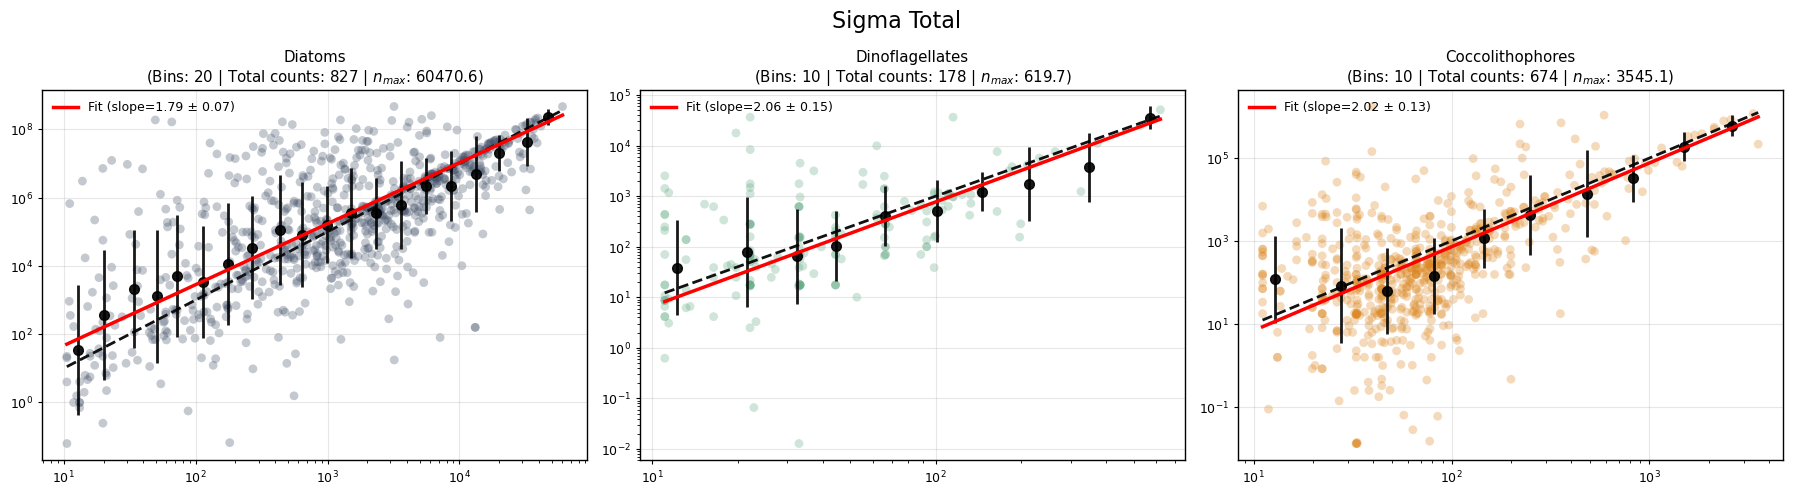

In [ ]:
raw_species_list = []
binned_species_list = []
params_species_list = []

raw_total_list = []
binned_total_list = []
params_total_list = []

fig_sp, axes_sp = plt.subplots(1, 3, figsize=(18, 5))
fig_sp.suptitle("Sigma Species", fontsize=16)

ax_idx = 0
for j, g in enumerate(unique_groups):
        
    ax = axes_sp[ax_idx]
    
    species_mask = groups_labels == g
    subset = species_matrix.iloc[species_mask, :].to_numpy()
    
    n_bins = 0
    total_counts = 0
    max_val = 0
    
    if subset.shape[1] >= 2:
        x_prev = subset[:, :-1]
        x_t = subset[:, 1:]
        
        mask_pos = (x_prev > 0) & (x_t > 10)
        x_prev, x_t = x_prev[mask_pos], x_t[mask_pos]
        
        if len(x_prev) >= 5:
            D = (x_t - x_prev)**2 / (tau)
            mask = (D > 1e-3)
            
            x_raw, y_raw = x_t[mask], D[mask]
            
            if len(x_raw) >= 3:
                total_counts = len(x_raw)
                max_val = np.max(x_raw)
                
                for i in range(len(x_raw)):
                    raw_species_list.append({
                        'Group_ID': j,
                        'Group_Name': group_names[j],
                        'x': x_raw[i],
                        'y': y_raw[i]
                    })
                
                ax.scatter(x_raw, y_raw, color=plot_palette[j], alpha=0.3, s=20, edgecolor='none')
                
                n_bins = 20 if j == 0 else 10
                x_mean, y_mean, y_low, y_high, std_logs = dynamic_log_binning(x_raw, y_raw, n_bins)
                
                if len(x_mean) > 0:
                    for i in range(len(x_mean)):
                        binned_species_list.append({
                            'Group_ID': j,
                            'Group_Name': group_names[j],
                            'x': x_mean[i],
                            'y': y_mean[i],
                            'y_low': y_low[i],
                            'y_high': y_high[i]
                        })

                    yerr = [np.maximum(0, y_mean - y_low), np.maximum(0, y_high - y_mean)]
                    ax.errorbar(x_mean, y_mean, yerr=yerr, fmt='o', color='black', ecolor='black', alpha=0.9, elinewidth=2, markersize=7, zorder=4)
                    
                    fit_mask = ~np.isnan(std_logs) & (std_logs > 0)
                    slope_val, slope_err, intercept_val = np.nan, np.nan, np.nan
                    if np.sum(fit_mask) >= 2:
                        try:
                            popt, pcov = curve_fit(linear_model, np.log10(x_mean[fit_mask]), np.log10(y_mean[fit_mask]), sigma=std_logs[fit_mask], absolute_sigma=False)
                            slope_val, intercept = popt
                            slope_err = np.sqrt(np.diag(pcov))[0]
                            intercept_val = intercept
                            
                            x_fit = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                            ax.plot(x_fit, 10**(intercept) * x_fit**slope_val, color='red', lw=2.5, label=f'Fit (slope={slope_val:.2f} ± {slope_err:.2f})', zorder=5)
                        except:
                            pass
                    
                    params_species_list.append({
                        'Group_ID': j,
                        'Group_Name': group_names[j],
                        'slope': slope_val,
                        'slope_err': slope_err,
                        'intercept': intercept_val
                    })
                
                x_ref = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                ax.plot(x_ref, 0.1 * x_ref**2, color='#111111', lw=2, linestyle='--', zorder=2)
                
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{group_names[j]}\n(Bins: {n_bins} | Total counts: {total_counts} | $n_{{max}}$: {max_val:.1f})")
    ax.legend(loc='upper left')
    
    ax_idx += 1

plt.tight_layout()
plt.show()

fig_tot, axes_tot = plt.subplots(1, 3, figsize=(18, 5))
fig_tot.suptitle("Sigma Total", fontsize=16)

ax_idx = 0
for j, name in enumerate(group_names):
    if str(name).strip().lower() == 'all':
        continue
        
    ax = axes_tot[ax_idx]
    
    series = df_groups.iloc[j, :].to_numpy()
    n_bins = 0
    total_counts = 0
    max_val = 0
    
    if len(series) >= 2:
        delta_t = (dates[1:].to_numpy() - dates[:-1].to_numpy()).astype('timedelta64[D]').astype(int)
        valid_dt = (delta_t >= 5) & (delta_t <= 9)
        x_prev = series[:-1][valid_dt]
        x_t = series[1:][valid_dt]
        
        mask_pos = (x_prev > 0) & (x_t > 10)
        x_prev, x_t = x_prev[mask_pos], x_t[mask_pos]
        
        if len(x_prev) >= 5:
            D = (x_t - x_prev)**2 / (tau)
            mask = (D > 1e-3)
            
            x_raw, y_raw = x_t[mask], D[mask]
            
            if len(x_raw) >= 3:
                total_counts = len(x_raw)
                max_val = np.max(x_raw)
                
                for i in range(len(x_raw)):
                    raw_total_list.append({
                        'Group_ID': j,
                        'Group_Name': group_names[j],
                        'x': x_raw[i],
                        'y': y_raw[i]
                    })
                
                ax.scatter(x_raw, y_raw, color=plot_palette[j], alpha=0.3, s=40, edgecolor='none')
                
                n_bins = 20 if j == 0 else 10
                x_mean, y_mean, y_low, y_high, std_logs = dynamic_log_binning(x_raw, y_raw, n_bins)
                
                if len(x_mean) > 0:
                    for i in range(len(x_mean)):
                        binned_total_list.append({
                            'Group_ID': j,
                            'Group_Name': group_names[j],
                            'x': x_mean[i],
                            'y': y_mean[i],
                            'y_low': y_low[i],
                            'y_high': y_high[i]
                        })

                    yerr = [np.maximum(0, y_mean - y_low), np.maximum(0, y_high - y_mean)]
                    ax.errorbar(x_mean, y_mean, yerr=yerr, fmt='o', color='black', ecolor='black', alpha=0.9, elinewidth=2, markersize=7, zorder=4)
                    
                    fit_mask = ~np.isnan(std_logs) & (std_logs > 0)
                    slope_val, slope_err, intercept_val = np.nan, np.nan, np.nan
                    if np.sum(fit_mask) >= 2:
                        try:
                            popt, pcov = curve_fit(linear_model, np.log10(x_mean[fit_mask]), np.log10(y_mean[fit_mask]), sigma=std_logs[fit_mask], absolute_sigma=False)
                            slope_val, intercept = popt
                            slope_err = np.sqrt(np.diag(pcov))[0]
                            intercept_val = intercept
                            
                            x_fit = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                            ax.plot(x_fit, 10**(intercept) * x_fit**slope_val, color='red', lw=2.5, label=f'Fit (slope={slope_val:.2f} ± {slope_err:.2f})', zorder=5)
                        except:
                            pass
                    
                    params_total_list.append({
                        'Group_ID': j,
                        'Group_Name': group_names[j],
                        'slope': slope_val,
                        'slope_err': slope_err,
                        'intercept': intercept_val
                    })
                
                x_ref_tot = np.logspace(np.log10(min(x_raw)), np.log10(max(x_raw)), 200)
                ax.plot(x_ref_tot, 0.1 * x_ref_tot**2, color='#111111', lw=2, linestyle='--', zorder=2)
                
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{group_names[j]}\n(Bins: {n_bins} | Total counts: {total_counts} | $n_{{max}}$: {max_val:.1f})")
    ax.legend(loc='upper left')
    
    ax_idx += 1

plt.tight_layout()
plt.show()


Lognormal fit

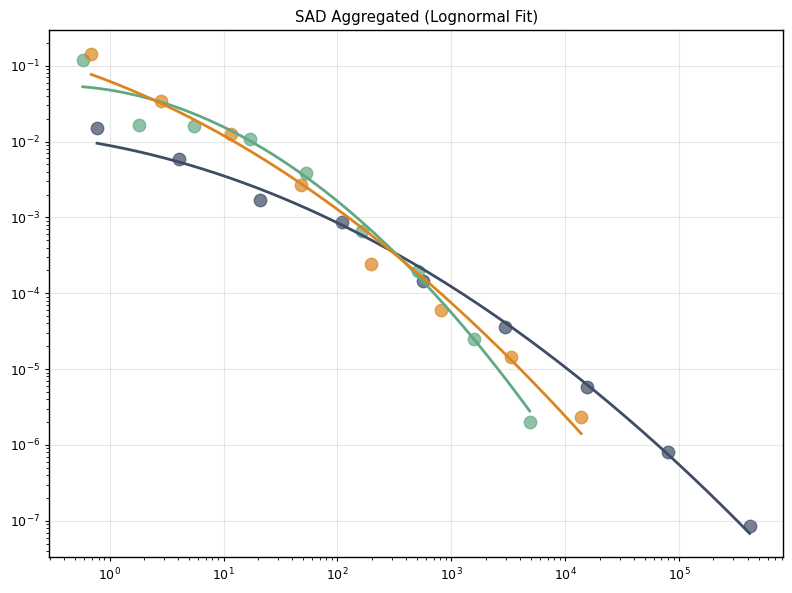

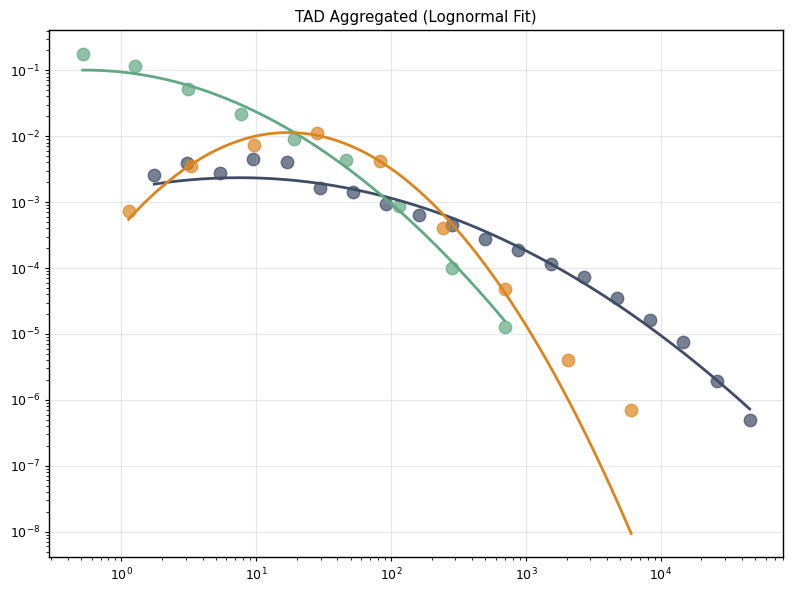

In [36]:
bic_SAD_lognorm_agg = np.full(3, np.nan)
mu_SAD_lognorm_agg = np.full(3, np.nan)
sigma_SAD_lognorm_agg = np.full(3, np.nan)

bic_TAD_lognorm_agg = np.full(3, np.nan)
mu_TAD_lognorm_agg = np.full(3, np.nan)
sigma_TAD_lognorm_agg = np.full(3, np.nan)

fig_sad, ax_sad = plt.subplots(figsize=(8, 6))
fig_tad, ax_tad = plt.subplots(figsize=(8, 6))

for j, g in enumerate(unique_groups):
    
    species_mask = groups_labels == g

    total_abund = species_matrix.iloc[species_mask, :].sum(axis=1)
    total_abund = total_abund[total_abund > 0]
    n_samples = len(total_abund)
    
    if n_samples >= 3:
        x_vals, y_vals = compute_pdf_log(total_abund, n_bins)
        if len(x_vals) > 0:
            ax_sad.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
            popt, pdf_data, nll = fit_distribution(total_abund, x_vals, y_vals)
            if popt is not None and pdf_data is not None:
                mu_SAD_lognorm_agg[j] = popt[0]
                sigma_SAD_lognorm_agg[j] = popt[1]
                bic_SAD_lognorm_agg[j] = 2 * np.log(n_samples) + 2 * nll
                ax_sad.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

ax_sad.set_xscale('log')
ax_sad.set_yscale('log')
ax_sad.grid(True, alpha=0.3)
ax_sad.set_title("SAD Aggregated (Lognormal Fit)")

for j, name in enumerate(group_names):
    if str(name).strip().lower() == 'all':
        continue
        
    vals = df_groups.iloc[j, :].to_numpy()
    vals = vals[vals > 0]
    n_samples = len(vals)
    
    if n_samples >= 3:
        x_vals, y_vals = compute_pdf_log(vals, 20 if j == 0 else 10)
        if len(x_vals) > 0:
            ax_tad.scatter(x_vals, y_vals, alpha=0.7, s=marker_size, color=plot_palette[j])
            popt, pdf_data, nll = fit_distribution(vals, x_vals, y_vals)
            if popt is not None and pdf_data is not None:
                mu_TAD_lognorm_agg[j] = popt[0]
                sigma_TAD_lognorm_agg[j] = popt[1]
                bic_TAD_lognorm_agg[j] = 2 * np.log(n_samples) + 2 * nll
                ax_tad.plot(pdf_data[0], pdf_data[1], lw=2, color=plot_palette[j])

ax_tad.set_xscale('log')
ax_tad.set_yscale('log')
ax_tad.grid(True, alpha=0.3)
ax_tad.set_title("TAD Aggregated (Lognormal Fit)")

fig_sad.tight_layout()
fig_tad.tight_layout()
plt.show()

DeltaBIC

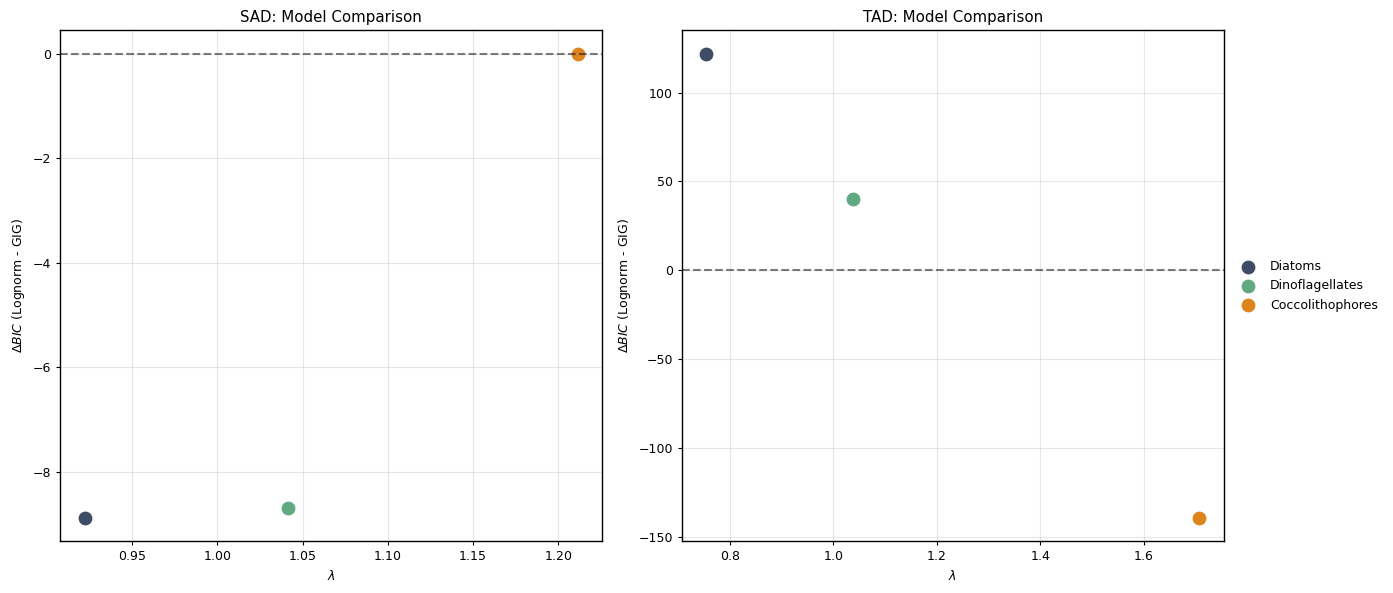

In [40]:
fig, (ax_sad, ax_tad) = plt.subplots(1, 2, figsize=(14, 6))

delta_bic_sad = bic_SAD_lognorm_agg - bic_SAD_gig_agg
x_sad = 2 * (1 - mu_SAD_agg)

for j, g in enumerate(unique_groups):
    if not np.isnan(delta_bic_sad[j]) and not np.isnan(x_sad[j]):
        ax_sad.scatter(x_sad[j], delta_bic_sad[j], color=plot_palette[j], s=marker_size, label=group_names[j])

ax_sad.axhline(0, color='black', linestyle='--', alpha=0.5)
ax_sad.set_xlabel(r"$\lambda$")
ax_sad.set_ylabel(r"$\Delta BIC$ (Lognorm - GIG)")
ax_sad.grid(True, alpha=0.3)
ax_sad.set_title("SAD: Model Comparison")

delta_bic_tad = bic_TAD_lognorm_agg - bic_TAD_gig_agg
x_tad = 2 * (1 - mu_TAD_agg)

for j, name in enumerate(group_names):
    if not np.isnan(delta_bic_tad[j]) and not np.isnan(x_tad[j]):
        ax_tad.scatter(x_tad[j], delta_bic_tad[j], color=plot_palette[j], s=marker_size, label=name)

ax_tad.axhline(0, color='black', linestyle='--', alpha=0.5)
ax_tad.set_xlabel(r"$\lambda$")
ax_tad.set_ylabel(r"$\Delta BIC$ (Lognorm - GIG)")
ax_tad.grid(True, alpha=0.3)
ax_tad.set_title("TAD: Model Comparison")

ax_tad.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
plt.show()